# EUR/DZD Black Market Rate — Time Series Analysis
### TSAC Individual Project 2025/2026 — Student: Kadouci Abdelhak

### Abstract

This project analyzes the EUR/DZD black market exchange rate using monthly data aggregated from daily observations spanning January 2016 to March 2026 (n = 123 observations). The series shows a strong upward trend, mild but visible annual seasonality, and several sharp shocks linked to political events, COVID-19, policy changes, and fiscal pressures. Box-Cox analysis indicated that no variance-stabilizing transformation was needed, while the Augmented Dickey-Fuller test confirmed that the original series was non-stationary and that first differencing (d = 1) was sufficient to achieve stationarity. ACF/PACF inspection and BIC-based model selection with `armasubsets()` identified **ARIMA(1,1,0)** as the best parsimonious non-seasonal model. However, forecast evaluation showed that this pure ARIMA specification converges too quickly to a flat path and fails to reproduce the yearly pattern visible in the data. We therefore extended the analysis to **SARIMA(1,1,0)(1,1,0)[12]**, which captures the seasonal structure and produces more realistic forecasts. Residual diagnostics indicate no statistically significant remaining autocorrelation at lag 12, but the Shapiro-Wilk test rejects normality, reflecting the heavy-tailed shocks present in this informal market. Overall, SARIMA(1,1,0)(1,1,0)[12] provides a more credible forecasting tool than the pure ARIMA baseline, although its prediction intervals should still be interpreted cautiously because unexpected exogenous shocks remain the main source of forecast error.

## Section 1: Introduction

The Algerian Dinar (DZD) operates under a dual exchange rate system: an official rate set by the Bank of Algeria, and an informal "black market" (or parallel market) rate that reflects the true supply and demand dynamics for foreign currency. For most Algerians, the parallel market rate — particularly against the Euro (EUR) — is the rate that matters in practice, as it governs the cost of imported goods, overseas travel, and remittances from the large Algerian diaspora in Europe.

Understanding and forecasting this parallel rate is of significant practical interest. Unlike the bank rate, which moves slowly and is managed by the central bank, the black market rate responds rapidly to economic fundamentals, political events, and policy changes. This makes it both more informative as an economic indicator and **more challenging** to model statistically.

### Data Source and Aggregation

The data used in this project consists of daily EUR/DZD sell rates from the parallel market, collected from **eurodz.com** for the period January 2016 to March 2026. While daily data provides a granular view, we have chosen to aggregate the observations into **monthly averages**.

There are several strategic reasons for this aggregation:
- **Data Quality:** Daily data often exhibits a "staircase" pattern where values remain identical for several consecutive days, which is typical of informal markets but less ideal for standard time series modeling.
- **Clarity:** Monthly averages filter out daily noise and minor fluctuations, providing a cleaner series that highlights long-term trends and seasonal cycles.
- **Relevance:** No meaningful daily seasonal patterns exist in this market; however, broader monthly trends—such as the impact of summer vacations or end-of-year fiscal pressures—are highly significant for economic analysis.

The goal of this project is to evaluate an appropriate modeling framework for this series and assess the drivers of these fluctuations.

### Environment Setup
Install and load the required R libraries for time series analysis.

In [110]:
install.packages(c("tidyverse","TSA", "tseries","httr","jsonlite"), repos = "https://cloud.r-project.org")
options(repr.plot.width=16, repr.plot.height=8)  # larger plots for better visibility

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [111]:
library(tidyverse) # neeed for aggregation
library(TSA)
library(tseries)
library(httr) # for fetching the data
library(jsonlite) # to deal with the json format and transform it

- Data: Daily EUR/DZD **black** market **sell rate** from 2016 to present.
- Data source: https://eurodz.com/ (scrapped from the historical plot).
- We will get our data from EURODZ api, returning a .json format data, with the fields (date, buyRate, sellRate, officialBuyRate, officialSellRate).
- For the whole project we will be working with the data aggragated **Monthly** (average of daily rates for each month).

In [ ]:
url <- "https://eurodz.com/api/data-294a869b196799a4.json" # fresh data
response <- GET(url)
df <- fromJSON(content(response, "text"), flatten = TRUE)
df$date <- as.Date(df$date)

No encoding supplied: defaulting to UTF-8.



- **Note**: the analysis was done only from Jan 2016 to 20 March 2026, that's why I am filtering up to 20 March 2026, if you want you can remove the filter and get the analysis up to the current date (may be different from the results obtained in the markdown cells), otherwise leave the code as it is.

In [113]:
# Filter up to 20 March 2026 -- The date this project was done
df <- df[df$date <= as.Date("2026-03-20"), ] # comment this if you want the analysis up to the current date

## Section 2: Model Specification

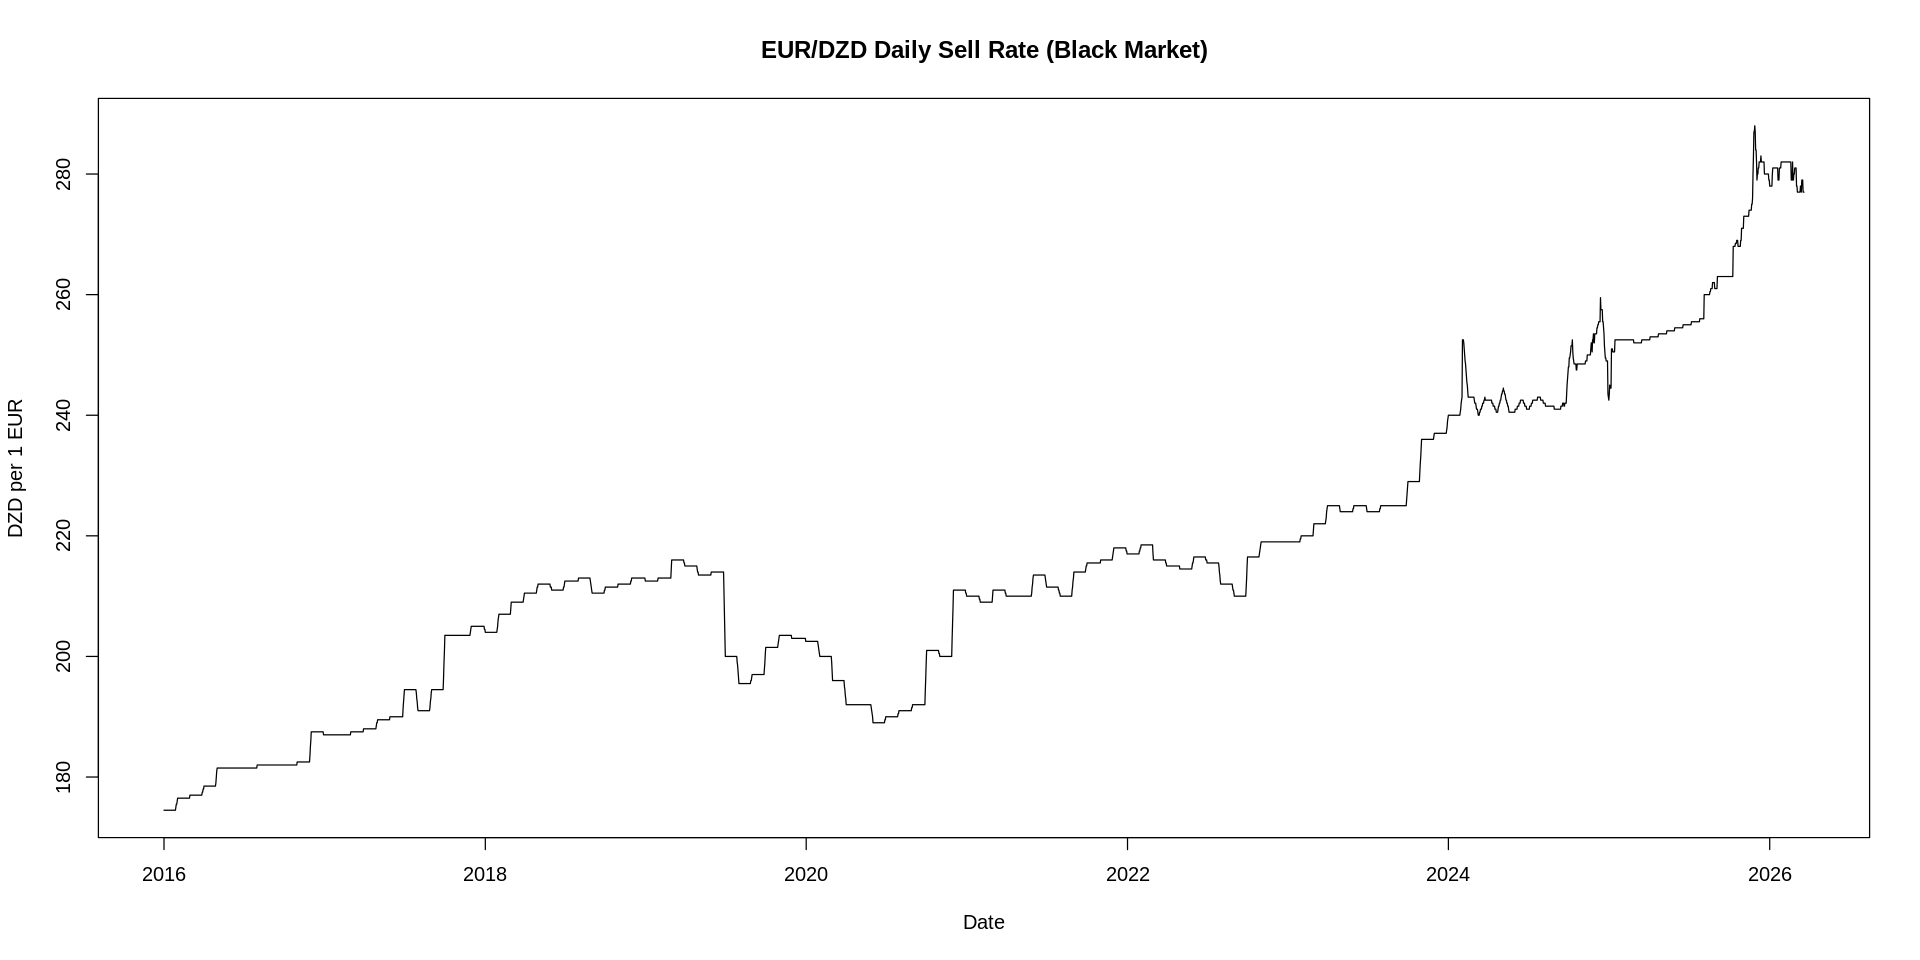

In [114]:
plot(df$date, df$sellRate, type="l",
     main="EUR/DZD Daily Sell Rate (Black Market)",
     ylab="DZD per 1 EUR", xlab="Date")

**Why aggregate to monthly averages?**
- Daily data has too many observations (+3300) and identical consecutive values (staircase shape)
- Daily data interpretation is less interesting
- No daily patterns exist
- Monthly data is cleaner for modeling, intrepretation and even forcasting.

In [115]:
df_monthly <- df %>%
  mutate(month = format(date, "%Y-%m")) %>%
  group_by(month) %>%
  summarise(sellRate = mean(sellRate)) %>%
  arrange(month)

y <- ts(df_monthly$sellRate, start=c(2016,1), frequency=12)
print(paste("n=", length(y)))

[1] "n= 123"


**Result — Monthly Aggregation:**
- The daily data has been aggregated into monthly averages and stored as a `ts` object `y` with `frequency=12` (monthly), starting January 2016.
- **n = 123 observations** — well above the n > 75 threshold for reliable time series modeling.
- We now proceed to visually explore this monthly series.

### Data Observation and Interpretation
Explore the monthly series visually, interpret its main features, and annotate the key events that help explain major movements in the EUR/DZD parallel rate.

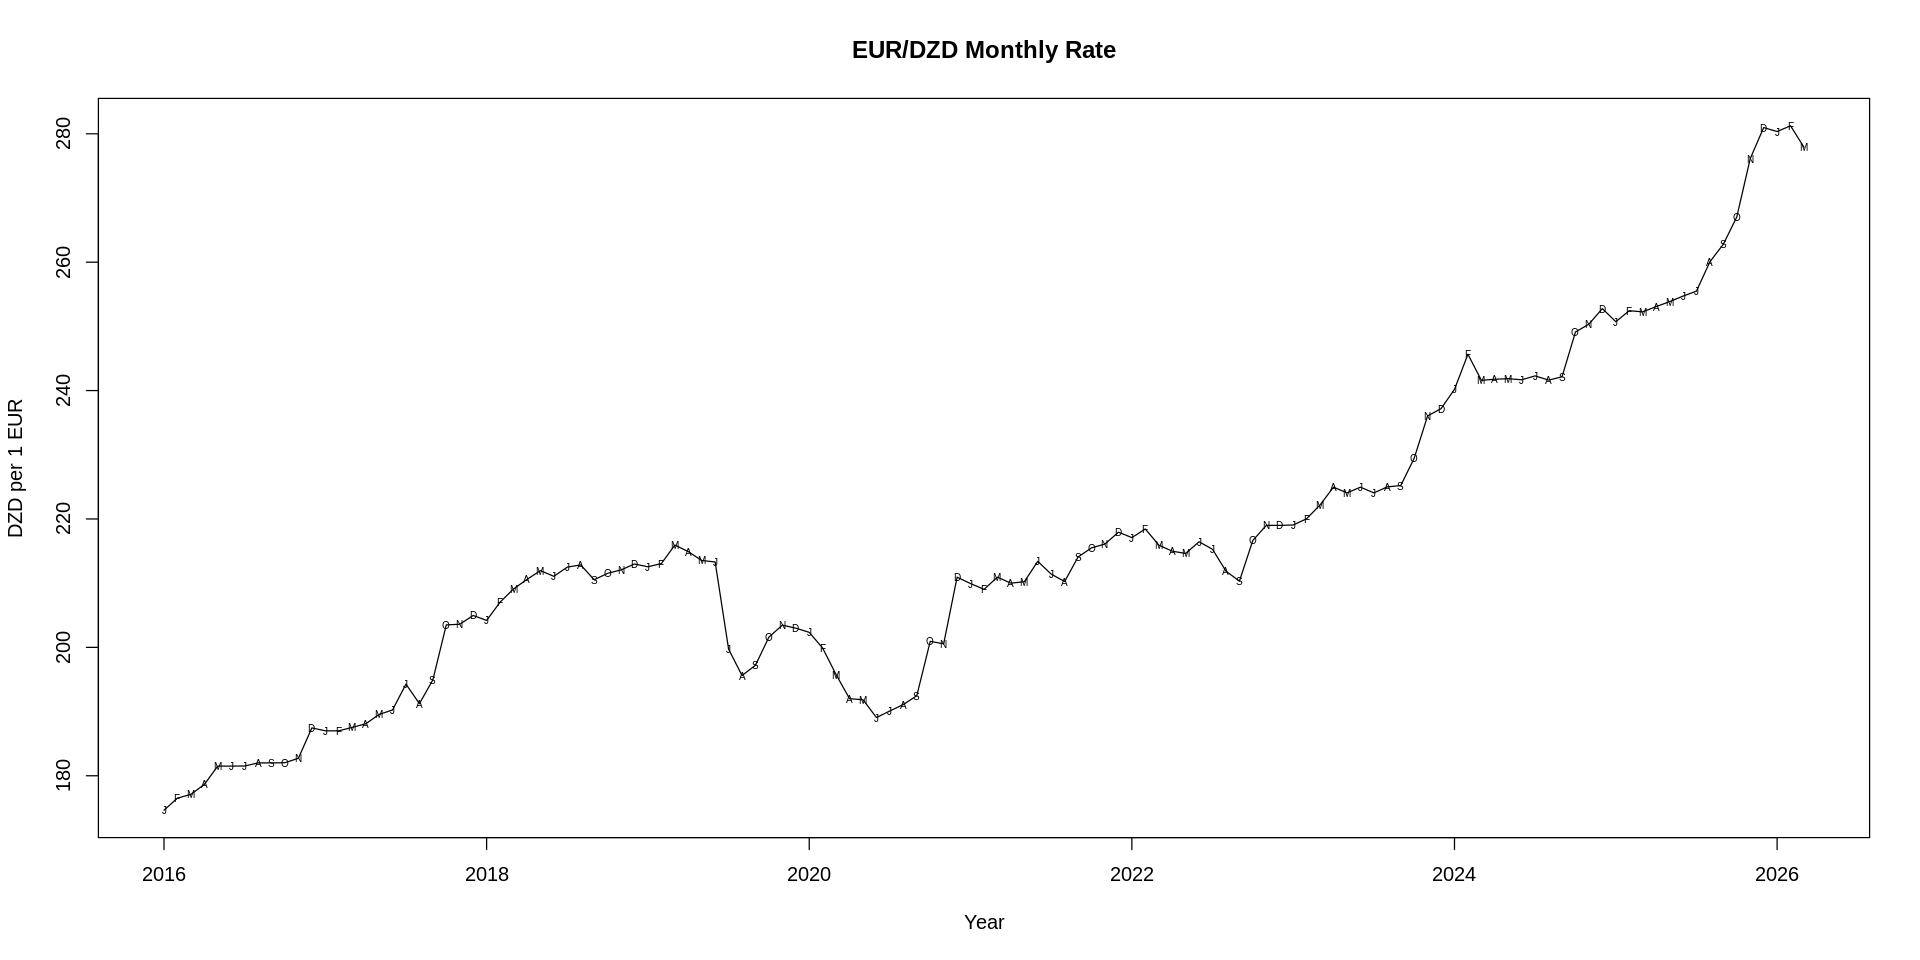

In [116]:
par(mfrow=c(1,1))
plot(y, main="EUR/DZD Monthly Rate",
     ylab="DZD per 1 EUR", xlab="Year", type='l', lwd=1)
points(y=y, x=time(y), pch=as.vector(season(y)),
       cex=0.5, lwd=2, col="black")

**Observations from the monthly plot:**
- The series appears **non-stationary** with a clear upward trend.
- Seasonality is quite visually apparent, some seasonal patterns exist (e.g. decreases during summer: June, July and increase in October).
- Several sharp spikes are visible (e.g. around 2020 due to COVID-19). These will be investigated below.

### Key Events and Seasonal Effects
This section links the main movements in the series to identifiable economic, political, policy, and COVID-related events. We begin with the first difference to highlight sudden changes, then return to the level series to show their impact on the exchange rate itself.

First we start with the first difference, and we try to intrepret the sharp spikes in the data, and the seasonality of the data

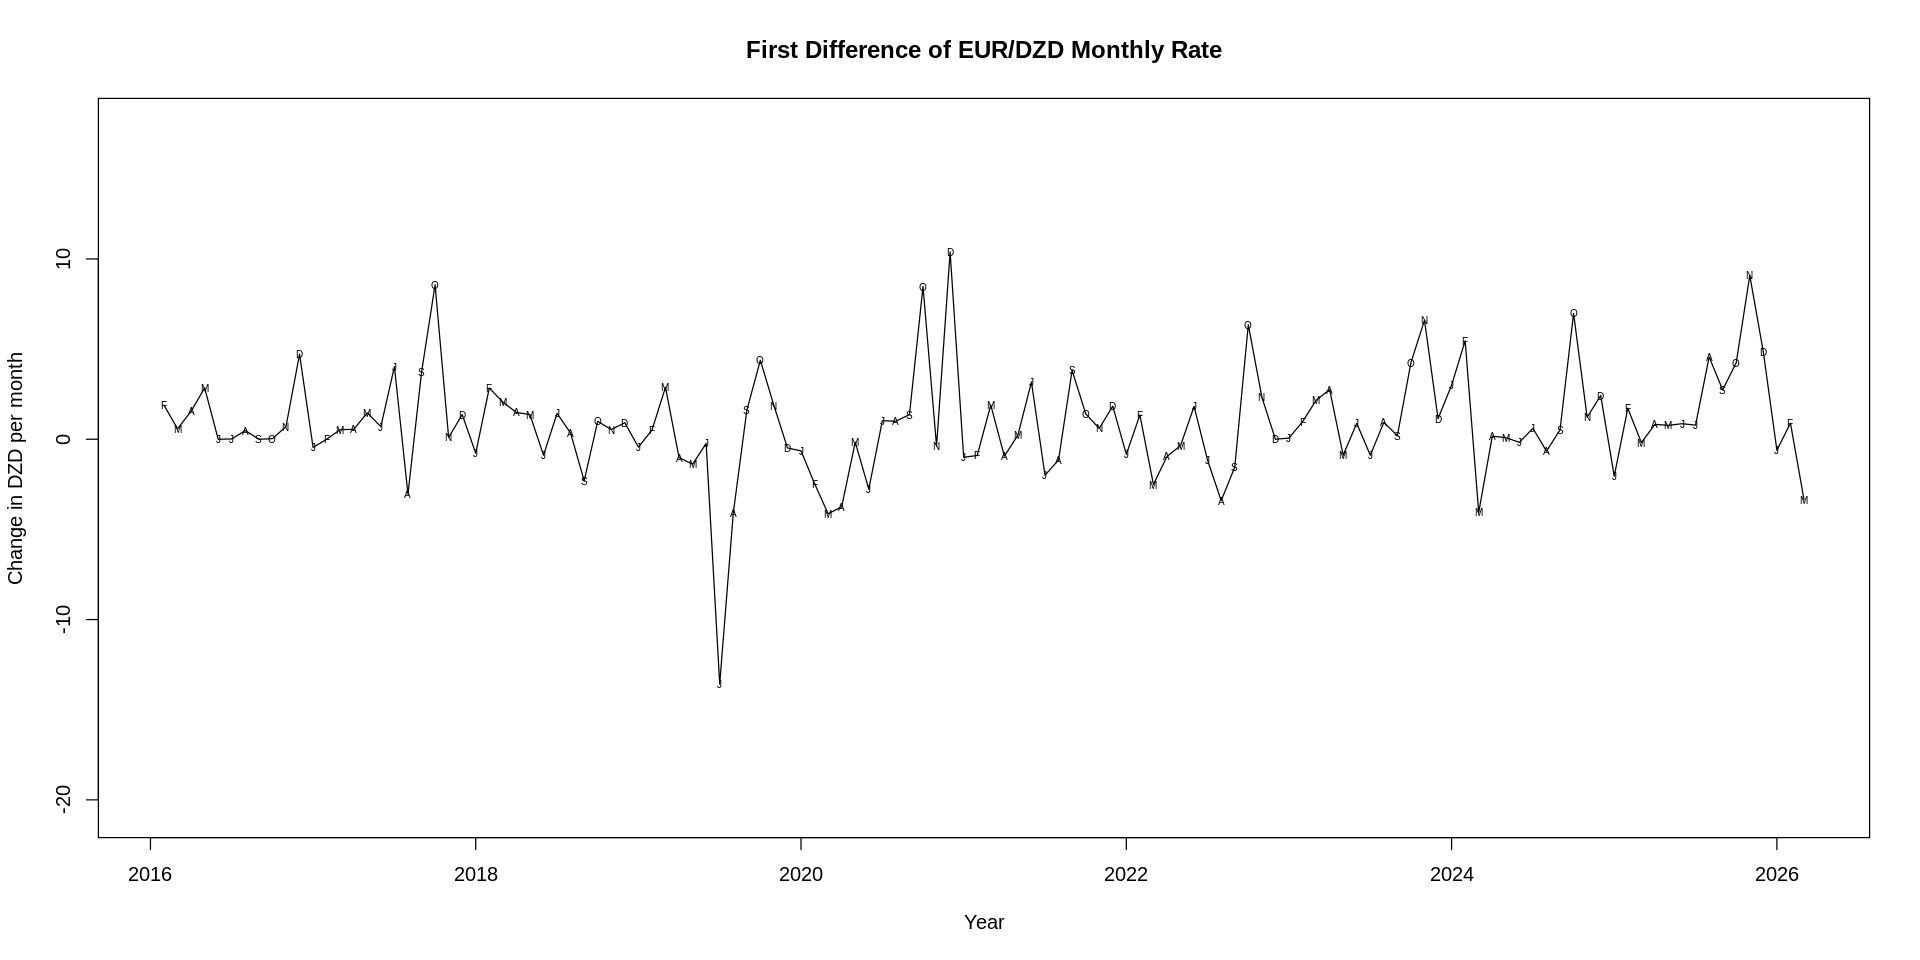

In [117]:
dy <- diff(y)

par(mfrow=c(1,1))
plot(dy, main="First Difference of EUR/DZD Monthly Rate",
     ylab="Change in DZD per month", xlab="Year", type='l', lwd=1,
     ylim=range(dy) + c(-7, 7))
# season() returns J,F,M,A,M,J,J,A,S,O,N,D for each observation
points(y=dy, x=time(dy), pch=as.vector(season(dy)),
       cex=0.5, lwd=2, col="black")

**Observation:**
- The differenced series oscillates around 0, confirming the upward trend might have been removed.
- The differenced series is stationary.
- We notice a slight seasonality: an increase in September, October, and a decrease in May, June, July, August (summer start) almost all the times-> Seasonality is visually apparent, interpretation:
    - Summer decrease: immigrants come back to their country for vaccation (usually summer June, July, August), and they need to exchange their money, which increases the demand for DZD -> decrease in DZD/EUR rate
    - September, October Increase: the end of the summer season, immigrants return, increasing the demand for EUR + Importing goods -> increase in DZD/EUR rate
- We also notice very sharp spikes in the data (e.g. June 2019: Hirak Crisis), which will be annotated in the next event plot, and explained in the report.
    - **Positive spikes** (rate increases): Oct 2020 (provincial travel resumes), Dec 2020 (flights resume), March 2023 (car import policy active), Oct 2022/2023 (car demand surges).
    - **Negative spikes** (rate drops): Apr 2019 (Hirak), Mar 2020 (COVID lockdown).


- **in short:** The sharp spikes in the series are beyond what the ARIMA model can capture. We note them for interpretation but proceed with standard ARIMA modeling, the first difference is stationary which means that d=1 is sufficient to achieve stationarity.

**Next step:** Doing a **DEEP** research to know what caused the unusual sharp changes, annotating these events (political, policy shocks...) directly on the first-difference, and showing the seasonal pattern in the plot. This will help us understand the real-world drivers of the rate changes and the seasonal behavior of the series.

**Note:** The detailed event annotations and their explanations will be included in the final report, with references to news articles and economic analyses that explain why these events caused the observed spikes in the EUR/DZD parallel rate.

#### Key Events & Seasonal Patterns Plot:

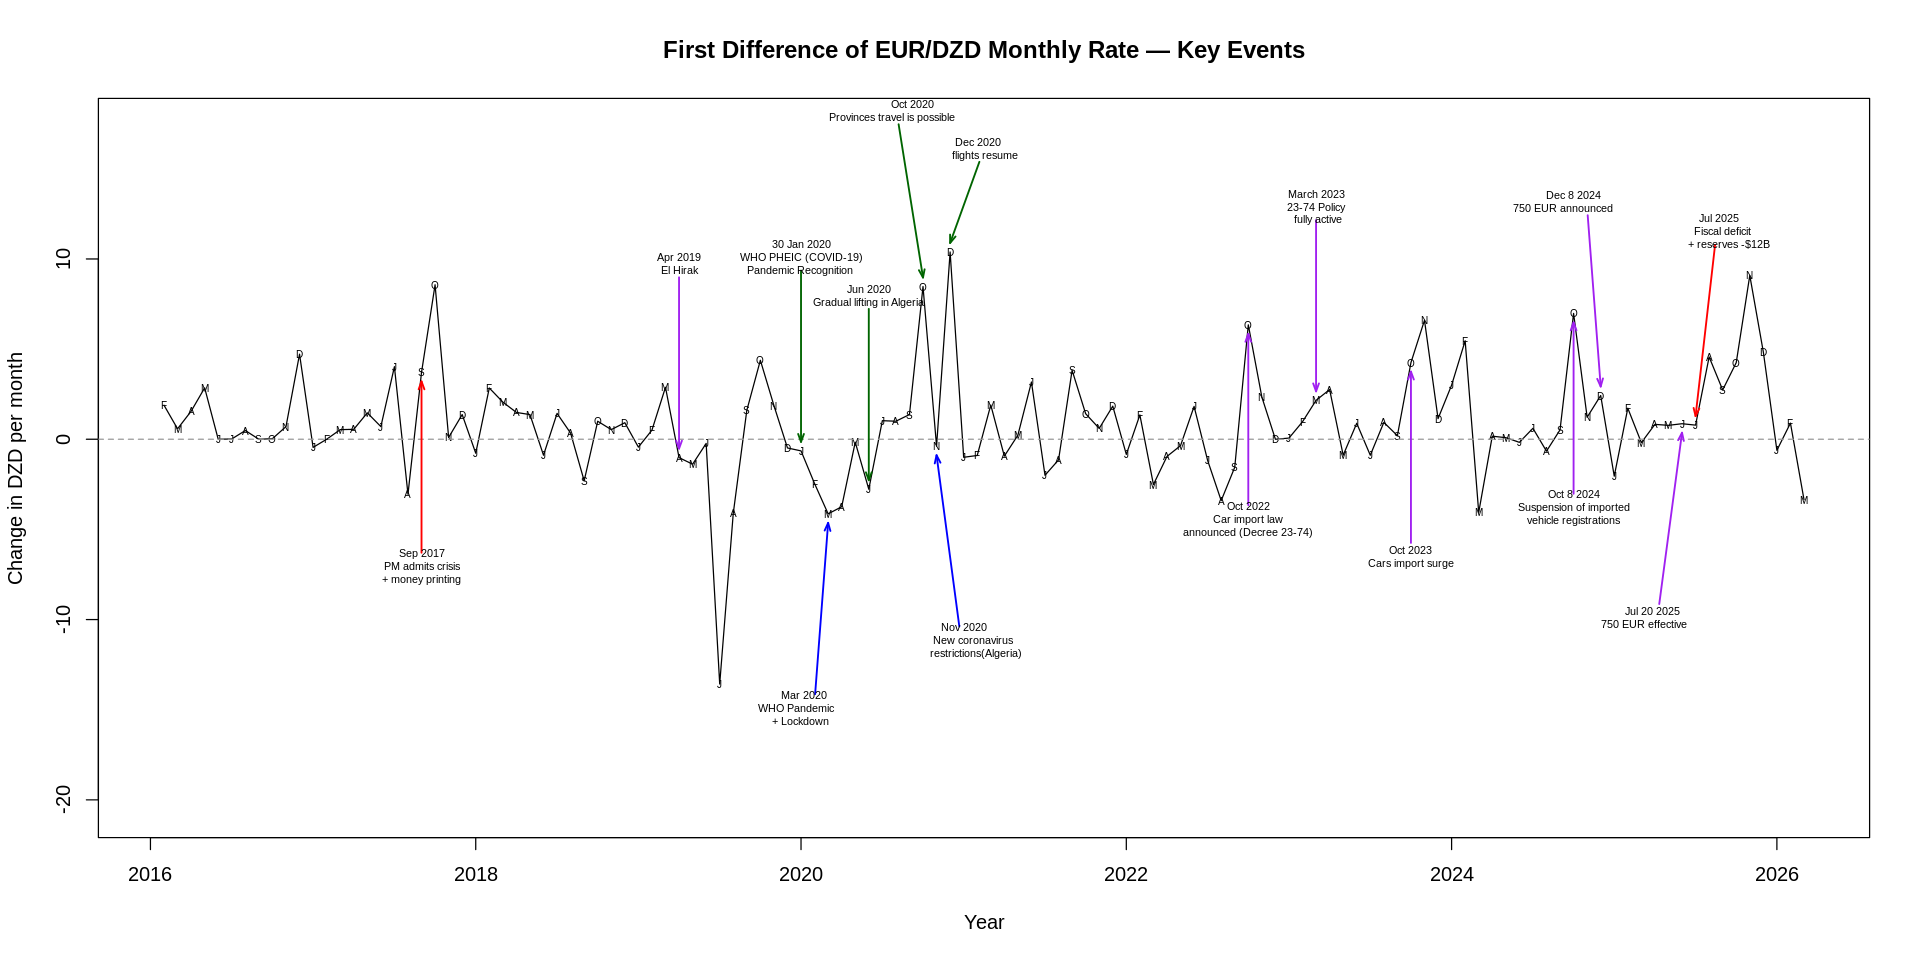

In [118]:
par(mfrow=c(1,1))
plot(dy, main="First Difference of EUR/DZD Monthly Rate — Key Events",
     ylab="Change in DZD per month", xlab="Year", type='l', lwd=1,
     ylim=range(dy) + c(-7, 7))


points(y=dy, x=time(dy), pch=as.vector(season(dy)),
       cex=0.5, lwd=2, col="black")

abline(h=0, col="gray60", lty=2)


# helper functions to not repeat time calculations for annotations
d <- function(year, month) year + (month-1)/12
get_dy <- function(year, month, offset=0) {
idx <- which.min(abs(time(dy) - d(year, month)))
as.numeric(dy)[idx] + offset
}

# plot parameters
tip     <- 0.5
tail    <- 10
txt     <- 10.75
arr_len <- 0.07
arr_ang <- 20
arr_lwd <- 1.5
txt_cex <- 0.54

# Financial crisis events (red)
arrows(x0=d(2017,9), y0=get_dy(2017,9, -tail),
       x1=d(2017,9), y1=get_dy(2017,9, -tip),
       length=arr_len, angle=arr_ang, lwd=arr_lwd, col="red")
text(d(2017,9), get_dy(2017,9, -txt),
     "Sep 2017\nPM admits crisis\n+ money printing",
     cex=txt_cex, col="black", srt=0, adj=0.5, font=1.5)

arrows(x0=d(2025,7)+0.12, y0=get_dy(2025,7, tail),
       x1=d(2025,7), y1=get_dy(2025,7, tip),
       length=arr_len, angle=arr_ang, lwd=arr_lwd, col="red")
text(d(2025,7)+0.08, get_dy(2025,7, txt),
     "Jul 2025\nFiscal deficit\n+ reserves -$12B",
     cex=txt_cex, col="black", srt=0, adj=0.25, font=1.5)

# Policy and political events (purple)
arrows(x0=d(2019,4), y0=get_dy(2019,4, tail),
       x1=d(2019,4), y1=get_dy(2019,4, tip),
       length=arr_len, angle=arr_ang, lwd=arr_lwd, col="purple")
text(d(2019,4), get_dy(2019,4, txt),
     "Apr 2019\nEl Hirak",
     cex=txt_cex, col="black", srt=0, adj=0.5, font=1.5)


arrows(x0=d(2022,10), y0=get_dy(2022,10, -tail),
       x1=d(2022,10), y1=get_dy(2022,10, -tip),
       length=arr_len, angle=arr_ang, lwd=arr_lwd, col="purple")
text(d(2022,10), get_dy(2022,10, -txt),
     "Oct 2022\nCar import law\nannounced (Decree 23-74)",
     cex=txt_cex, col="black", srt=0, adj=0.5, font=1.5)

arrows(x0=d(2023,3), y0=get_dy(2023,3, tail),
       x1=d(2023,3), y1=get_dy(2023,3, tip),
       length=arr_len, angle=arr_ang, lwd=arr_lwd, col="purple")
text(d(2023,3), get_dy(2023,3, txt),
     "March 2023\n23-74 Policy\n fully active",
     cex=txt_cex, col="black", srt=0, adj=0.5, font=1.5)

arrows(x0=d(2023,10), y0=get_dy(2023,10, -tail),
       x1=d(2023,10), y1=get_dy(2023,10, -tip),
       length=arr_len, angle=arr_ang, lwd=arr_lwd, col="purple")
text(d(2023,10), get_dy(2023,10, -txt),
     "Oct 2023\nCars import surge",
     cex=txt_cex, col="black", srt=0, adj=0.5, font=1.5)

arrows(x0=d(2024,12)-0.08, y0=get_dy(2024,12, tail),
       x1=d(2024,12), y1=get_dy(2024,12, tip),
       length=arr_len, angle=arr_ang, lwd=arr_lwd, col="purple")
text(d(2024,12)-0.08, get_dy(2024,12, txt),
     "Dec 8 2024\n750 EUR announced",
     cex=txt_cex, col="black", srt=0, adj=0.75, font=1.5)

arrows(x0=d(2025,6)-0.14, y0=get_dy(2025,6, -tail),
       x1=d(2025,6), y1=get_dy(2025,6, -tip),
       length=arr_len, angle=arr_ang, lwd=arr_lwd, col="purple")
text(d(2025,6)-0.1, get_dy(2025,6, -txt),
     "Jul 20 2025\n750 EUR effective",
     cex=txt_cex, col="black", srt=0, adj=0.75, font=1.5)

arrows(x0=d(2024,10), y0=get_dy(2024,10, -tail),
       x1=d(2024,10), y1=get_dy(2024,10, -tip),
       length=arr_len, angle=arr_ang, lwd=arr_lwd, col="purple")
text(d(2024,10), get_dy(2024,10, -txt),
     "Oct 8 2024\nSuspension of imported\nvehicle registrations",
     cex=txt_cex, col="black", srt=0, adj=0.5, font=1.5)

# COVID events: green for increases, blue for decreases
arrows(x0=d(2020,10)-0.15, y0=get_dy(2020,10, tail-1),
       x1=d(2020,10), y1=get_dy(2020,10, tip),
       length=arr_len, angle=arr_ang, lwd=arr_lwd, col="darkgreen")
text(d(2020,10), get_dy(2020,10, txt-1),
     "Oct 2020\nProvinces travel is possible",
     cex=txt_cex, col="black", srt=0, adj=0.75, font=1.5)

arrows(x0=d(2020,12)+0.18, y0=get_dy(2020,12, tail-5),
       x1=d(2020,12), y1=get_dy(2020,12, tip),
       length=arr_len, angle=arr_ang, lwd=arr_lwd, col="darkgreen")
text(d(2020,12)+0.1, get_dy(2020,12, txt-5),
     "Dec 2020\n flights resume",
     cex=txt_cex, col="black", srt=0, adj=0.25, font=1.5)

arrows(x0=d(2020,1), y0=get_dy(2020,1, tail),
       x1=d(2020,1), y1=get_dy(2020,1, tip),
       length=arr_len, angle=arr_ang, lwd=arr_lwd, col="darkgreen")
text(d(2020,1), get_dy(2020,1, txt),
     "30 Jan 2020\nWHO PHEIC (COVID-19)\nPandemic Recognition ",
     cex=txt_cex, col="black", srt=0, adj=0.5, font=1.5)

arrows(x0=d(2020,6), y0=get_dy(2020,6, tail),
       x1=d(2020,6), y1=get_dy(2020,6, tip),
       length=arr_len, angle=arr_ang, lwd=arr_lwd, col="darkgreen")
text(d(2020,6), get_dy(2020,6, txt),
     "Jun 2020\nGradual lifting in Algeria",
     cex=txt_cex, col="black", srt=0, adj=0.5, font=1.5)

arrows(x0=d(2020,3)-0.08, y0=get_dy(2020,3, -tail),
       x1=d(2020,3), y1=get_dy(2020,3, -tip),
       length=arr_len, angle=arr_ang, lwd=arr_lwd, col="blue")
text(d(2020,3)-0.08, get_dy(2020,3, -txt),
     "Mar 2020\nWHO Pandemic\n+ Lockdown",
     cex=txt_cex, col="black", srt=0, adj=0.75, font=1.5)

arrows(x0=d(2020,11)+0.14, y0=get_dy(2020,11, -tail),
       x1=d(2020,11), y1=get_dy(2020,11, -tip),
       length=arr_len, angle=arr_ang, lwd=arr_lwd, col="blue")
text(d(2020,11)+0.1, get_dy(2020,11, -txt),
     "Nov 2020\nNew coronavirus\nrestrictions(Algeria)",
     cex=txt_cex, col="black", srt=0, adj=0.25, font=1.5)

#### Annotated Original Series with Key Events
Now we annotate the same events on the **original (level) series** to see their impact on the actual EUR/DZD rate rather than the month-to-month changes.

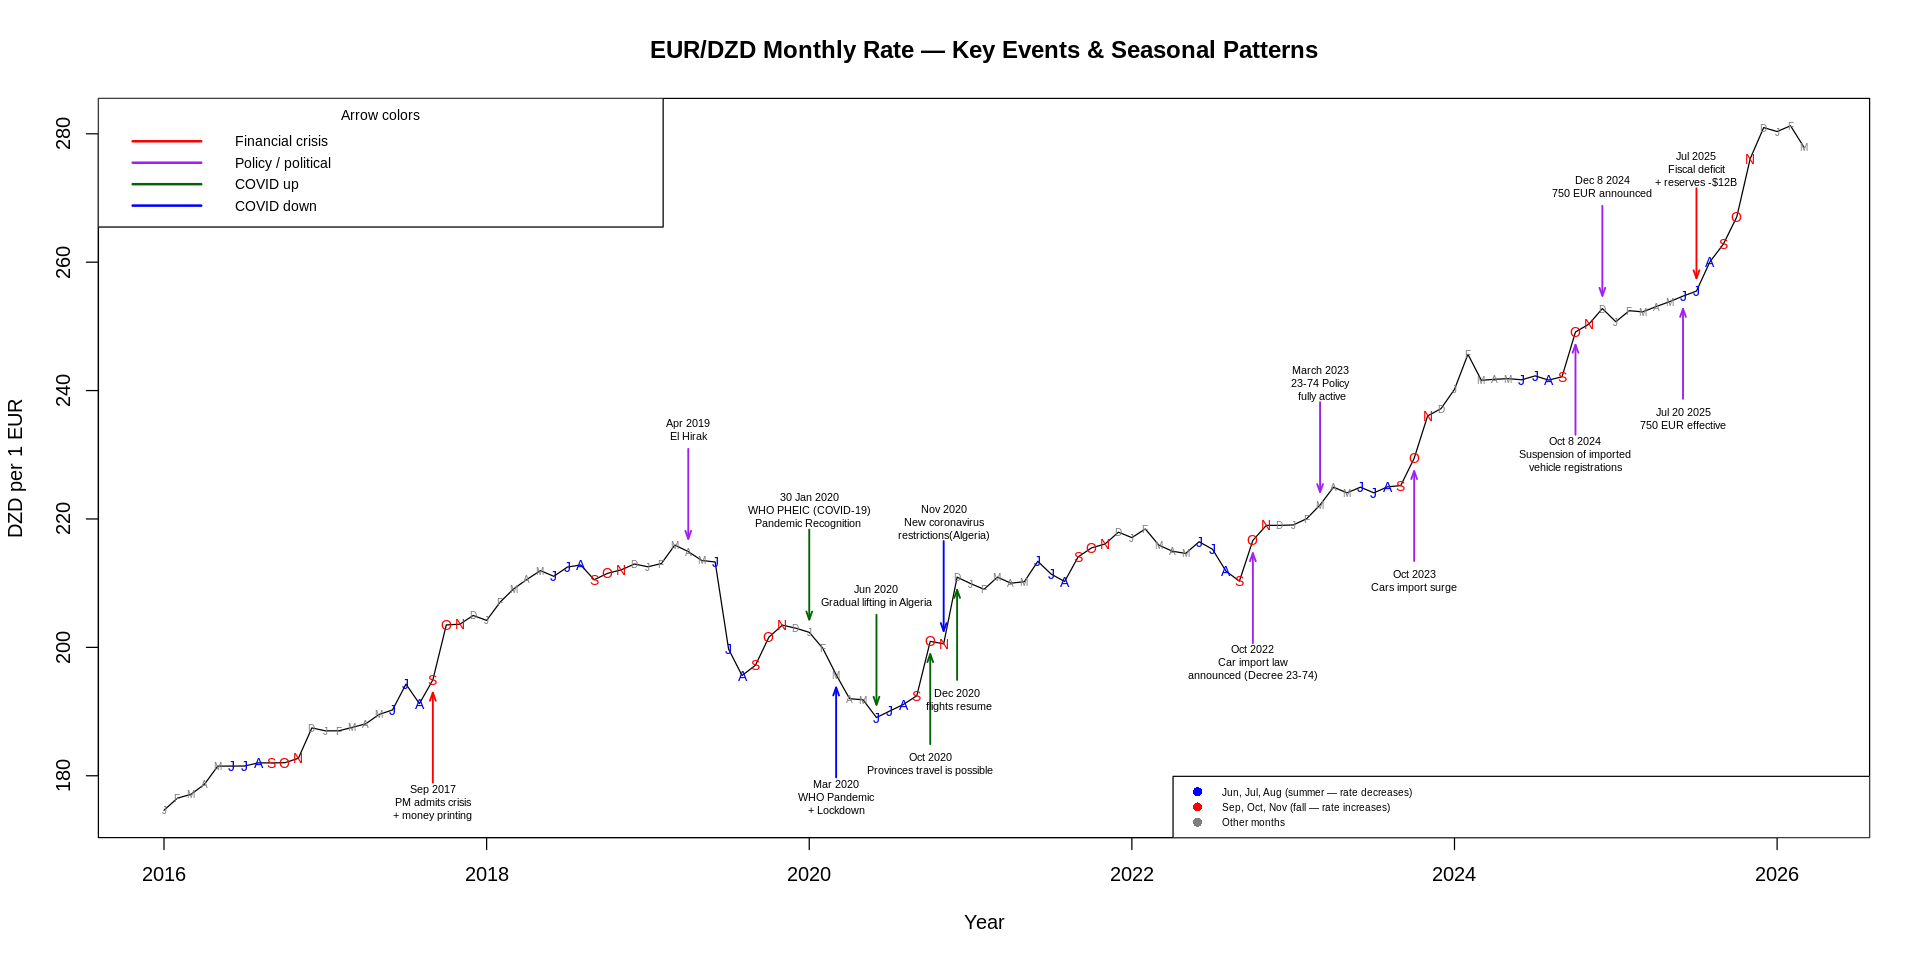

In [119]:
par(mfrow=c(1,1))
plot(y, main="EUR/DZD Monthly Rate — Key Events & Seasonal Patterns",
     ylab="DZD per 1 EUR", xlab="Year", type='l', lwd=1)

seas <- as.vector(season(y))
t_dy <- time(y)
dy_vals <- as.numeric(y)
cyc <- cycle(y)

# Summer months —>  typically decrease
summer <- cyc %in% c(6, 7, 8)
# Fall months —> typically increase
fall   <- cyc %in% c(9, 10, 11)
other  <- !summer & !fall

# plot each group with distinct colors
points(t_dy[summer], dy_vals[summer],
       pch=seas[summer], cex=0.7, lwd=2, col="blue")
points(t_dy[fall], dy_vals[fall],
       pch=seas[fall], cex=0.7, lwd=2, col="red")
points(t_dy[other], dy_vals[other],
       pch=seas[other], cex=0.5, lwd=1.5, col="gray50")

legend("bottomright",
       legend=c("Jun, Jul, Aug (summer — rate decreases)",
                "Sep, Oct, Nov (fall — rate increases)",
                "Other months"),
       col=c("blue", "red", "gray50"), pch=c(16, 16, 16),
       pt.cex=1, cex=0.5, bg="white")


legend("topleft",
       legend=c("Financial crisis", "Policy / political", "COVID up", "COVID down"),
       col=c("red", "purple", "darkgreen", "blue"),
       lty=1, lwd=2, cex=0.7, bg="white", title="Arrow colors")

d <- function(year, month) year + (month-1)/12

get_y <- function(year, month, offset=0) {
  idx <- which.min(abs(time(y) - d(year, month)))
  as.numeric(y)[idx] + offset
}

tip     <- 2
tail    <- 16
txt     <- 19
arr_len <- 0.07
arr_ang <- 20
arr_lwd <- 1.5
txt_cex <- 0.54

# Financial crisis events (red)
arrows(x0=d(2017,9), y0=get_y(2017,9, -tail),
       x1=d(2017,9), y1=get_y(2017,9, -tip),
       length=arr_len, angle=arr_ang, lwd=arr_lwd, col="red")
text(d(2017,9), get_y(2017,9, -txt),
     "Sep 2017\nPM admits crisis\n+ money printing",
     cex=txt_cex, col="black", srt=0, adj=0.5, font=1.5)

arrows(x0=d(2025,7), y0=get_y(2025,7, tail),
       x1=d(2025,7), y1=get_y(2025,7, tip),
       length=arr_len, angle=arr_ang, lwd=arr_lwd, col="red")
text(d(2025,7), get_y(2025,7, txt),
     "Jul 2025\nFiscal deficit\n+ reserves -$12B",
     cex=txt_cex, col="black", srt=0, adj=0.5, font=1.5)

# Policy and political events (purple)
arrows(x0=d(2019,4), y0=get_y(2019,4, tail),
       x1=d(2019,4), y1=get_y(2019,4, tip),
       length=arr_len, angle=arr_ang, lwd=arr_lwd, col="purple")
text(d(2019,4), get_y(2019,4, txt),
     "Apr 2019\nEl Hirak",
     cex=txt_cex, col="black", srt=0, adj=0.5, font=1.5)

arrows(x0=d(2022,10), y0=get_y(2022,10, -tail),
       x1=d(2022,10), y1=get_y(2022,10, -tip),
       length=arr_len, angle=arr_ang, lwd=arr_lwd, col="purple")
text(d(2022,10), get_y(2022,10, -txt),
     "Oct 2022\nCar import law\nannounced (Decree 23-74)",
     cex=txt_cex, col="black", srt=0, adj=0.5, font=1.5)

arrows(x0=d(2023,3), y0=get_y(2023,3, tail),
       x1=d(2023,3), y1=get_y(2023,3, tip),
       length=arr_len, angle=arr_ang, lwd=arr_lwd, col="purple")
text(d(2023,3), get_y(2023,3, txt),
     "March 2023\n23-74 Policy\n fully active",
     cex=txt_cex, col="black", srt=0, adj=0.5, font=1.5)

arrows(x0=d(2023,10), y0=get_y(2023,10, -tail),
       x1=d(2023,10), y1=get_y(2023,10, -tip),
       length=arr_len, angle=arr_ang, lwd=arr_lwd, col="purple")
text(d(2023,10), get_y(2023,10, -txt),
     "Oct 2023\nCars import surge",
     cex=txt_cex, col="black", srt=0, adj=0.5, font=1.5)

arrows(x0=d(2024,12), y0=get_y(2024,12, tail),
       x1=d(2024,12), y1=get_y(2024,12, tip),
       length=arr_len, angle=arr_ang, lwd=arr_lwd, col="purple")
text(d(2024,12), get_y(2024,12, txt),
     "Dec 8 2024\n750 EUR announced",
     cex=txt_cex, col="black", srt=0, adj=0.5, font=1.5)

arrows(x0=d(2025,6), y0=get_y(2025,6, -tail),
       x1=d(2025,6), y1=get_y(2025,6, -tip),
       length=arr_len, angle=arr_ang, lwd=arr_lwd, col="purple")
text(d(2025,6), get_y(2025,6, -txt),
     "Jul 20 2025\n750 EUR effective",
     cex=txt_cex, col="black", srt=0, adj=0.5, font=1.5)

arrows(x0=d(2024,10), y0=get_y(2024,10, -tail),
       x1=d(2024,10), y1=get_y(2024,10, -tip),
       length=arr_len, angle=arr_ang, lwd=arr_lwd, col="purple")
text(d(2024,10), get_y(2024,10, -txt),
     "Oct 8 2024\nSuspension of imported\nvehicle registrations",
     cex=txt_cex, col="black", srt=0, adj=0.5, font=1.5)

# COVID events: green for increases, blue for decreases
arrows(x0=d(2020,10), y0=get_y(2020,10, -tail),
       x1=d(2020,10), y1=get_y(2020,10, -tip),
       length=arr_len, angle=arr_ang, lwd=arr_lwd, col="darkgreen")
text(d(2020,10), get_y(2020,10, -txt),
     "Oct 2020\nProvinces travel is possible",
     cex=txt_cex, col="black", srt=0, adj=0.5, font=1.5)

arrows(x0=d(2020,12), y0=get_y(2020,12, -tail),
       x1=d(2020,12), y1=get_y(2020,12, -tip),
       length=arr_len, angle=arr_ang, lwd=arr_lwd, col="darkgreen")
text(d(2020,12), get_y(2020,12, -txt),
     "Dec 2020\n flights resume",
     cex=txt_cex, col="black", srt=0, adj=0.5, font=1.5)

arrows(x0=d(2020,1), y0=get_y(2020,1, tail),
       x1=d(2020,1), y1=get_y(2020,1, tip),
       length=arr_len, angle=arr_ang, lwd=arr_lwd, col="darkgreen")
text(d(2020,1), get_y(2020,1, txt),
     "30 Jan 2020\nWHO PHEIC (COVID-19)\nPandemic Recognition ",
     cex=txt_cex, col="black", srt=0, adj=0.5, font=1.5)

arrows(x0=d(2020,6), y0=get_y(2020,6, tail),
       x1=d(2020,6), y1=get_y(2020,6, tip),
       length=arr_len, angle=arr_ang, lwd=arr_lwd, col="darkgreen")
text(d(2020,6), get_y(2020,6, txt),
     "Jun 2020\nGradual lifting in Algeria",
     cex=txt_cex, col="black", srt=0, adj=0.5, font=1.5)

arrows(x0=d(2020,3), y0=get_y(2020,3, -tail),
       x1=d(2020,3), y1=get_y(2020,3, -tip),
       length=arr_len, angle=arr_ang, lwd=arr_lwd, col="blue")
text(d(2020,3), get_y(2020,3, -txt),
     "Mar 2020\nWHO Pandemic\n+ Lockdown",
     cex=txt_cex, col="black", srt=0, adj=0.5, font=1.5)

arrows(x0=d(2020,11), y0=get_y(2020,11, tail),
       x1=d(2020,11), y1=get_y(2020,11, tip),
       length=arr_len, angle=arr_ang, lwd=arr_lwd, col="blue")
text(d(2020,11), get_y(2020,11, txt),
     "Nov 2020\nNew coronavirus\nrestrictions(Algeria)",
     cex=txt_cex, col="black", srt=0, adj=0.5, font=1.5)

**Observation:**
- The series has many significant jumps or drops in the exchange rate; a problem since ARIMA models assume normally distributed errors and no **large outliers**.
- The annotated plot confirms the major movements correspond to real-world events and, the color scheme separates them by type.
    - **Red arrows:** financial-crisis shocks such as money printing and the later fiscal deficit pressure.
    - **Purple arrows:** policy and political events such as Hirak, oligarch arrests, car-import regulation changes, and the 750 EUR allowance announcements.
    - **Green arrows:** COVID-related events associated with upward moves in the rate, mainly reopening and easing measures.
    - **Blue arrows:** COVID-related events associated with downward moves in the rate, mainly lockdowns and renewed restrictions.
- **in short:** The series is non-stationary, seasonal with many outliers. We proceed to formal modeling in Section 3.

### Stationarity, Differencing, and Order Identification
Checking with tests for variance stabilization, stationarity, differencing, and ACF/PACF analysis to identify ARIMA orders.

### Step 1: Check if variance stabilization is needed
- **Box-Cox transformation:** $Y_t^{(\lambda)} = (Y_t^\lambda - 1) / \lambda$
  - $\lambda = 1$ → no transformation needed
  - $\lambda = 0$ → log transformation: $\log(Y_t)$
- `BoxCox.ar()` estimates the optimal $\lambda$ by maximizing the log-likelihood.

Warning message in arima0(x, order = c(i, 0L, 0L), include.mean = demean):
“possible convergence problem: optim gave code = 1”


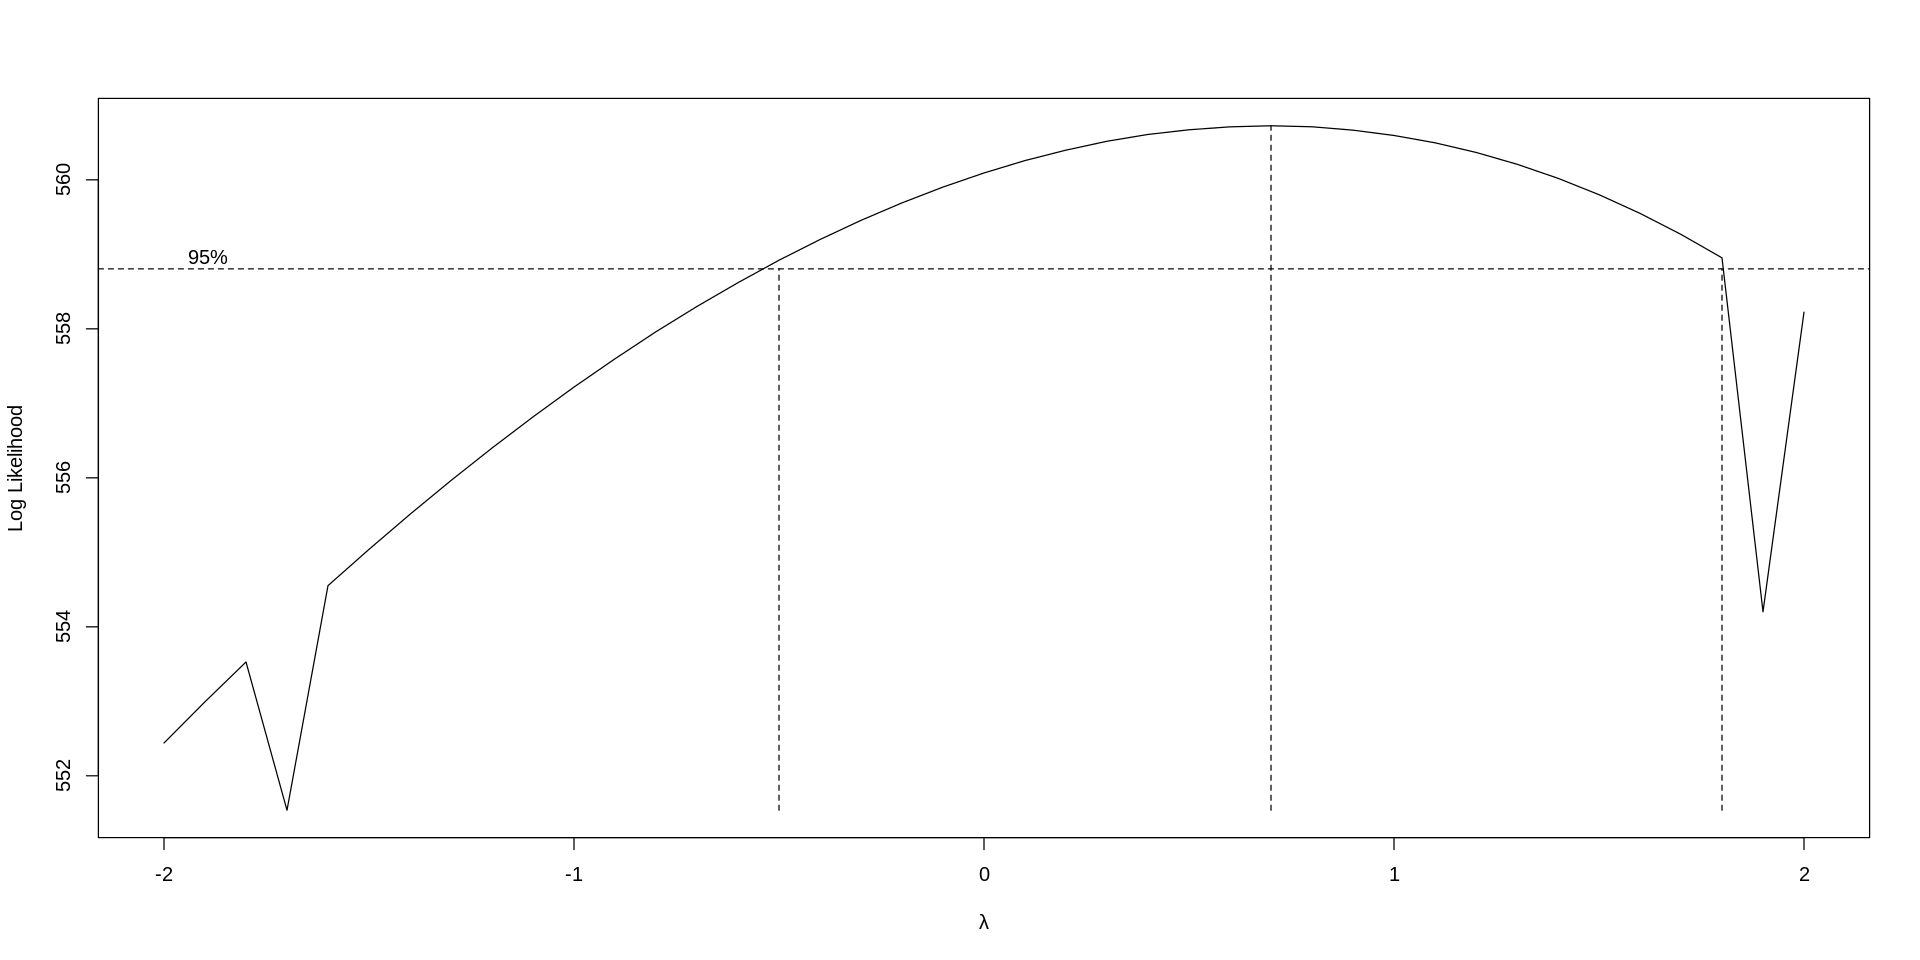

In [120]:
BoxCox.ar(y)

**Result — Box-Cox:**
- The Box-Cox confidence interval contains both $\lambda = 1$ and $\lambda = 0$. This means the data do not give strong evidence that a transformation is necessary.
- When this happens, we usually choose the **simplest and most interpretable option**, which is $\lambda = 1$ because it keeps the series in its original DZD/EUR scale.
- Choosing $\lambda = 1$ avoids transforming the data unnecessarily. A log transform ($\lambda = 0$) is only preferred when there is clear evidence of non-constant variance or multiplicative variation.
- Here, since $\lambda = 1$ is acceptable and there is no strong need to stabilize the variance, we keep the original series unchanged.
- **Decision:** no variance-stabilizing transformation is needed, so we continue the analysis with the original monthly rate series.

### Step 2: Test for stationarity on original series
- **ADF test:**
  - H0: series has a unit root (non-stationary)
  - H1: series is stationary

In [121]:
adf.test(y)


	Augmented Dickey-Fuller Test

data:  y
Dickey-Fuller = -0.98752, Lag order = 4, p-value = 0.9367
alternative hypothesis: stationary


**Result — ADF Test (Original Series):**
- p-value = 0.937 >> 0.05 → **fail to reject H0**
- The series is **NOT stationary** (same conclusion obtained from visual inspection) → we must difference.

### Steps 3–4: First difference and stationarity re-test
- **Differencing:** $\nabla Y_t = Y_t - Y_{t-1}$
- This removes the linear trend, giving $d = 1$ in ARIMA(p,d,q).
- After differencing, we re-apply the ADF test to confirm stationarity.

Warning message in adf.test(dy):
“p-value smaller than printed p-value”



	Augmented Dickey-Fuller Test

data:  dy
Dickey-Fuller = -4.9102, Lag order = 4, p-value = 0.01
alternative hypothesis: stationary


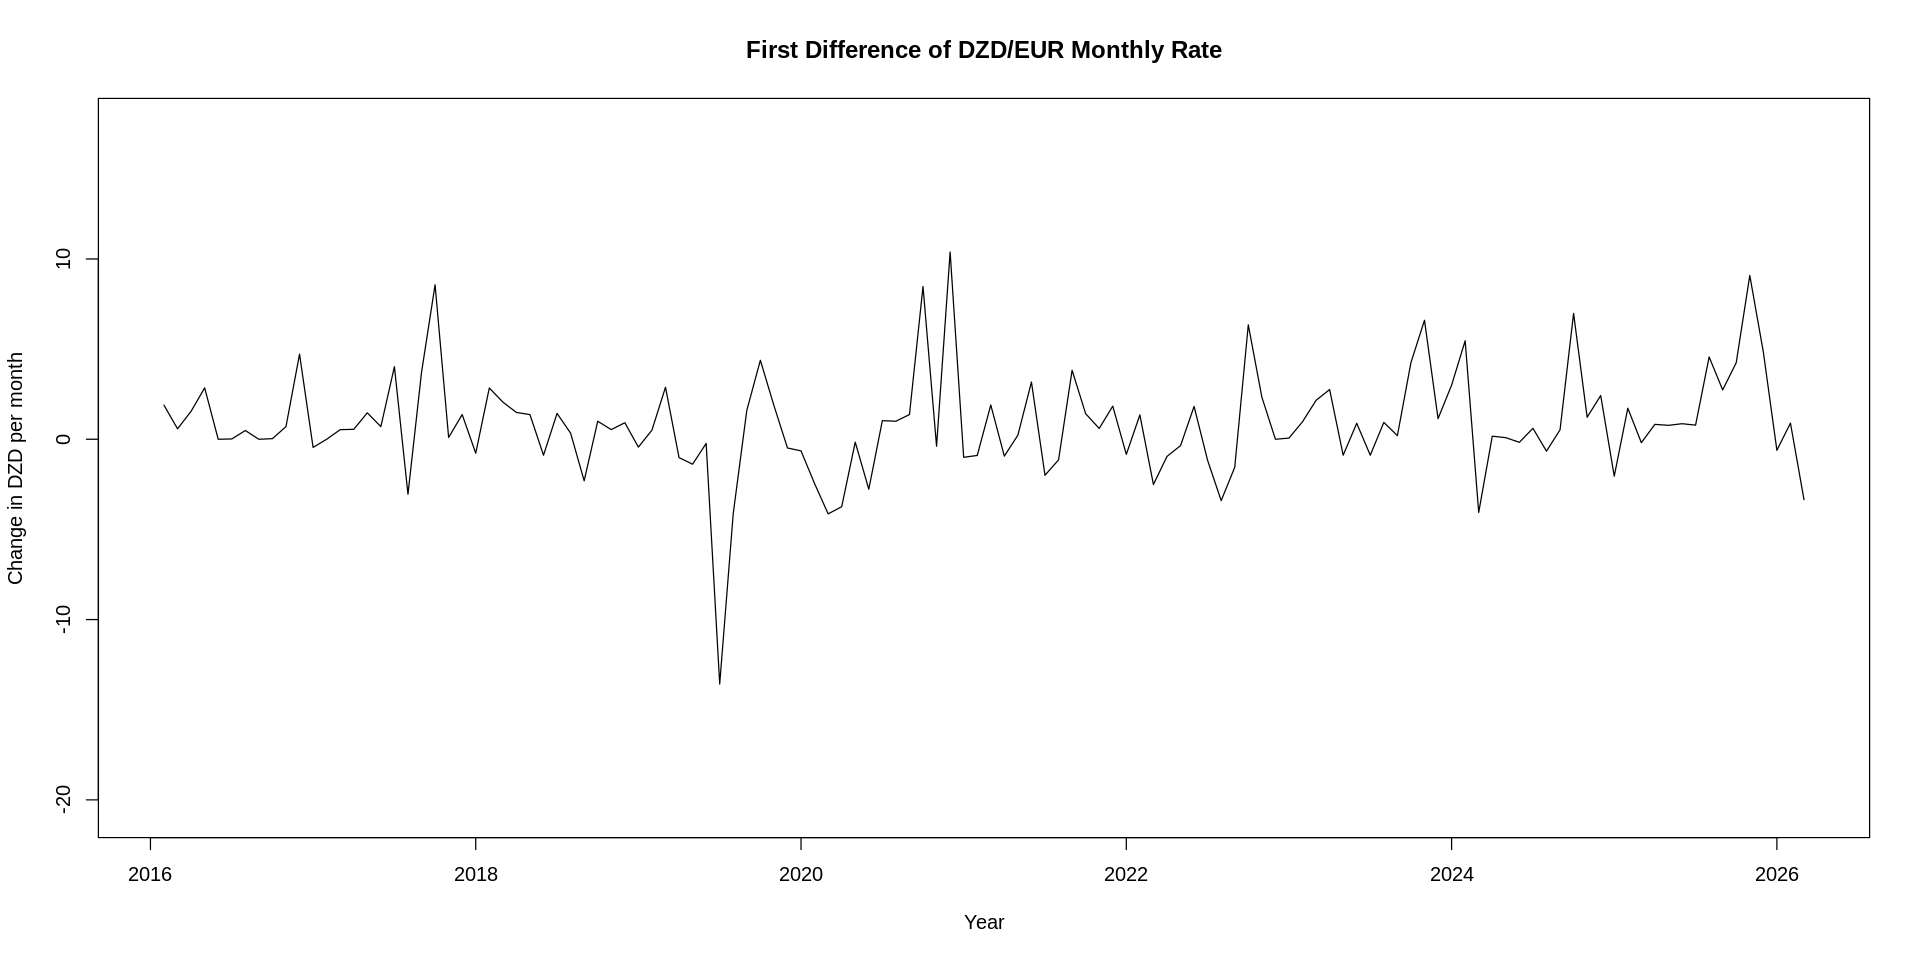

In [122]:
dy <- diff(y)

plot(dy, main="First Difference of DZD/EUR Monthly Rate",
     ylab="Change in DZD per month", xlab="Year", type='l', lwd=1,
     ylim=range(dy) + c(-7, 7))
adf.test(dy)

**Result — Differenced Series:**
- The plot of $\nabla Y_t$ oscillates around zero, which confirms that one difference removes the main trend in the original series.
- The ADF test on the differenced series gives **p-value = 0.01 < 0.05**, so we reject the unit-root null hypothesis.
- **Conclusion:** one difference is sufficient, therefore the ARIMA differencing order is <u>**d = 1**</u>.

### Step 5: ACF and PACF to identify p and q
- **ACF** $(\rho_k)$: correlation between $Y_t$ and $Y_{t-k}$
- **PACF** $(\phi_{kk})$: correlation between $Y_t$ and $Y_{t-k}$ after removing the effect of intermediate lags
- **Reading rules:**
  - ACF cuts off at lag $q$, PACF decays → **MA(q)** process
  - PACF cuts off at lag $p$, ACF decays → **AR(p)** process
  - Both decay slowly → **ARMA(p,q)** process

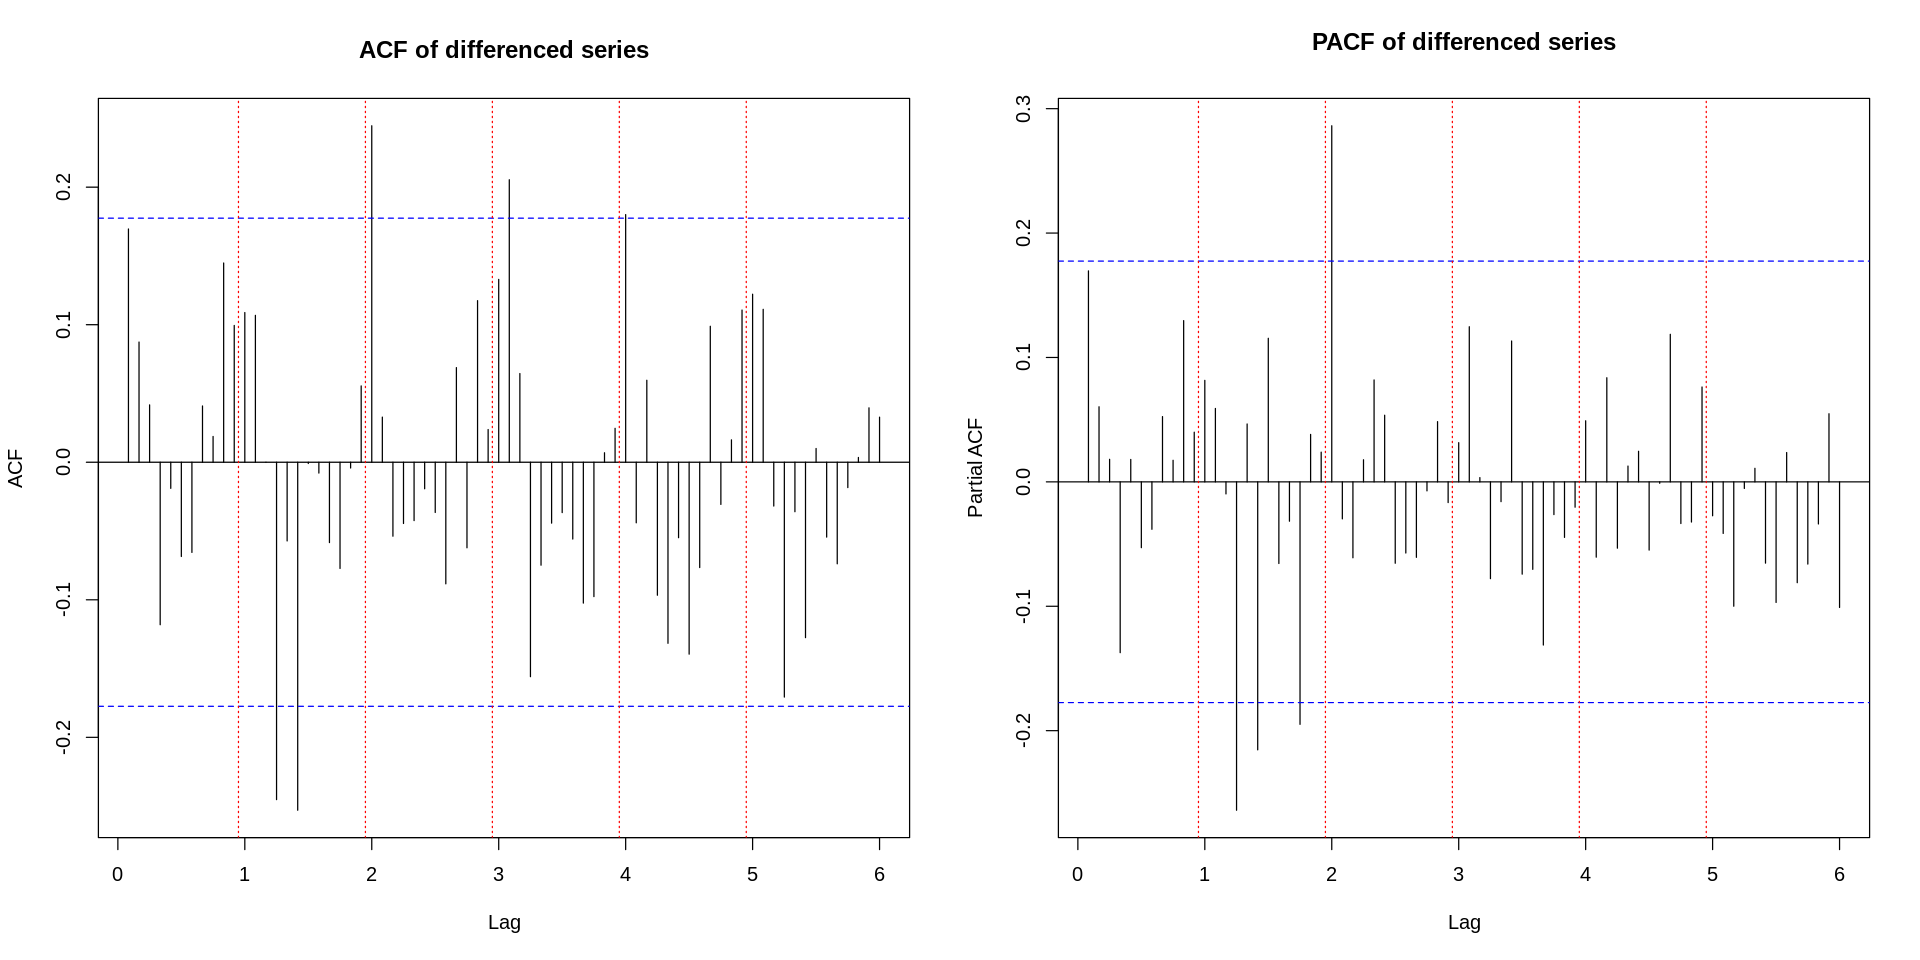

In [123]:
par(mfrow=c(1,2))
acf(dy, lag.max=72, main="ACF of differenced series")
abline(v=0.95:4.95, col="red", lty=3)

pacf(dy, lag.max=72, main="PACF of differenced series")
abline(v=0.95:4.95, col="red", lty=3)

**Result — ACF/PACF Analysis:**
- The x-axis is shown in **years** because the series is monthly with `frequency = 12`. Thus lag `1` means **12 months**, lag `2` means **24 months**, and so on.
- The series is seems to be seasonal, since the autocorrelations at lag `x` is closely similar to the autocorrelation at lag `x + 12k` (e.g. lag 1 and lag 13, lag 2 and lag 14, etc.) — this suggests a seasonal pattern with period 12.
- We see how the ACF and PACF behave at different lags and in different years (**ignoring** some spikes in the data) to identify the AR and MA orders:
    - **ACF:** Many times prominent spike occurs at the first lag, while many other remaining spikes stay inside the confidence bands. A few moderate correlations appear around yearly seasonal positions.
    - **PACF:** The most prominent spike occurs at the first lag; after that, the partial autocorrelations become much smaller, **ignoring** some spikes in the data.
- **Conclusion:** I suggest a candidates such as **ARIMA(1,1,1)**, while nearby alternatives like **ARIMA(0,1,1)** and **ARIMA(1,1,0)** are still worth checking.

### Step 6: armasubsets() for BIC-based model selection
- `armasubsets()` fits all possible ARMA(p,q) subsets up to `(nar, nma)` and ranks them by BIC.
- **BIC** $= -2\log L + k\log(n)$ — lower BIC = better model (penalizes complexity).
- The **darkest row** in the plot corresponds to the best (lowest BIC) model.

Warning message in leaps.setup(x, y, wt = wt, nbest = nbest, nvmax = nvmax, force.in = force.in, :
“11  linear dependencies found”


Reordering variables and trying again:


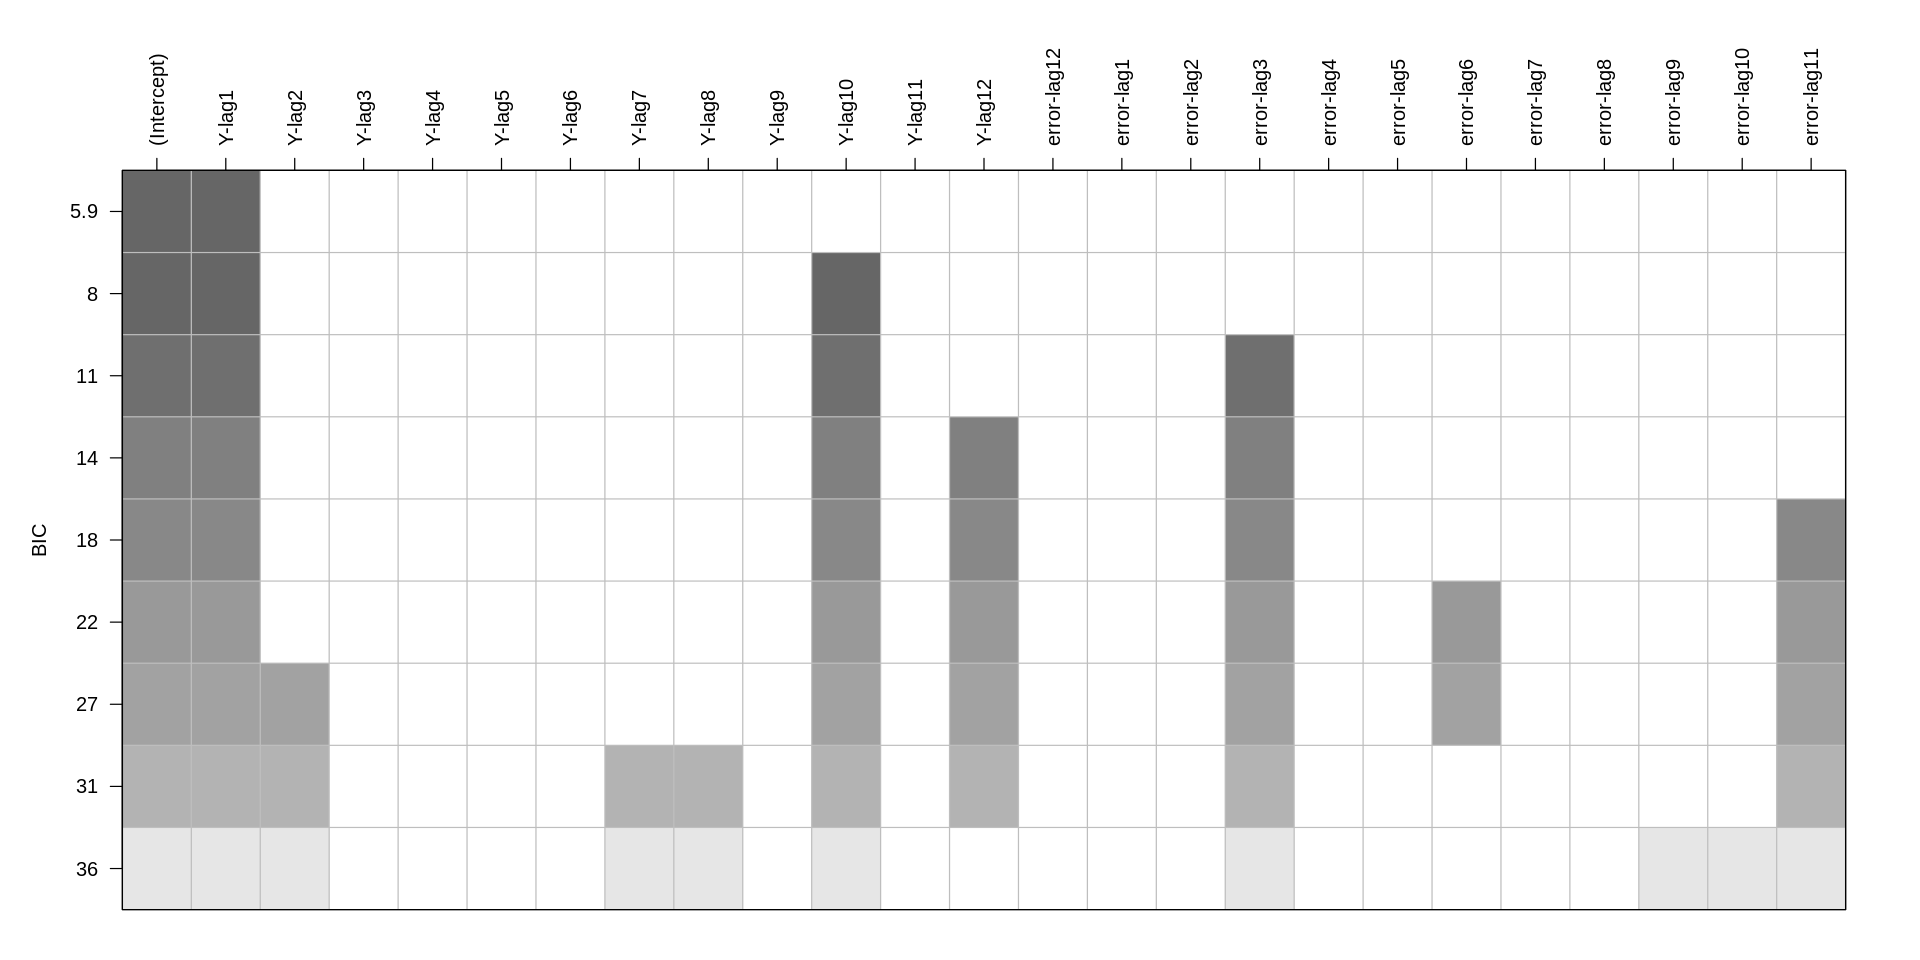

In [124]:
par(mfrow=c(1,1))
plot(armasubsets(dy, nar=12, nma=12))

**Result — armasubsets BIC:**
- The **darkest row** (lowest BIC ≈ 5.9) selects only **(Intercept)** and **Y-lag1** — corresponding to an **AR(1)** on the differenced series.
- This suggests: the best parsimonious model is **ARIMA(1,1,0)** based on BIC.
- No MA terms are selected in the top model.

## Section 3: Fitting and Diagnostics



### ARIMA(1,1,0)
BIC selected AR(1) on the differenced series, i.e. **ARIMA(1,1,0)**. Let's fit it and check whether it adequately captures the series dynamics

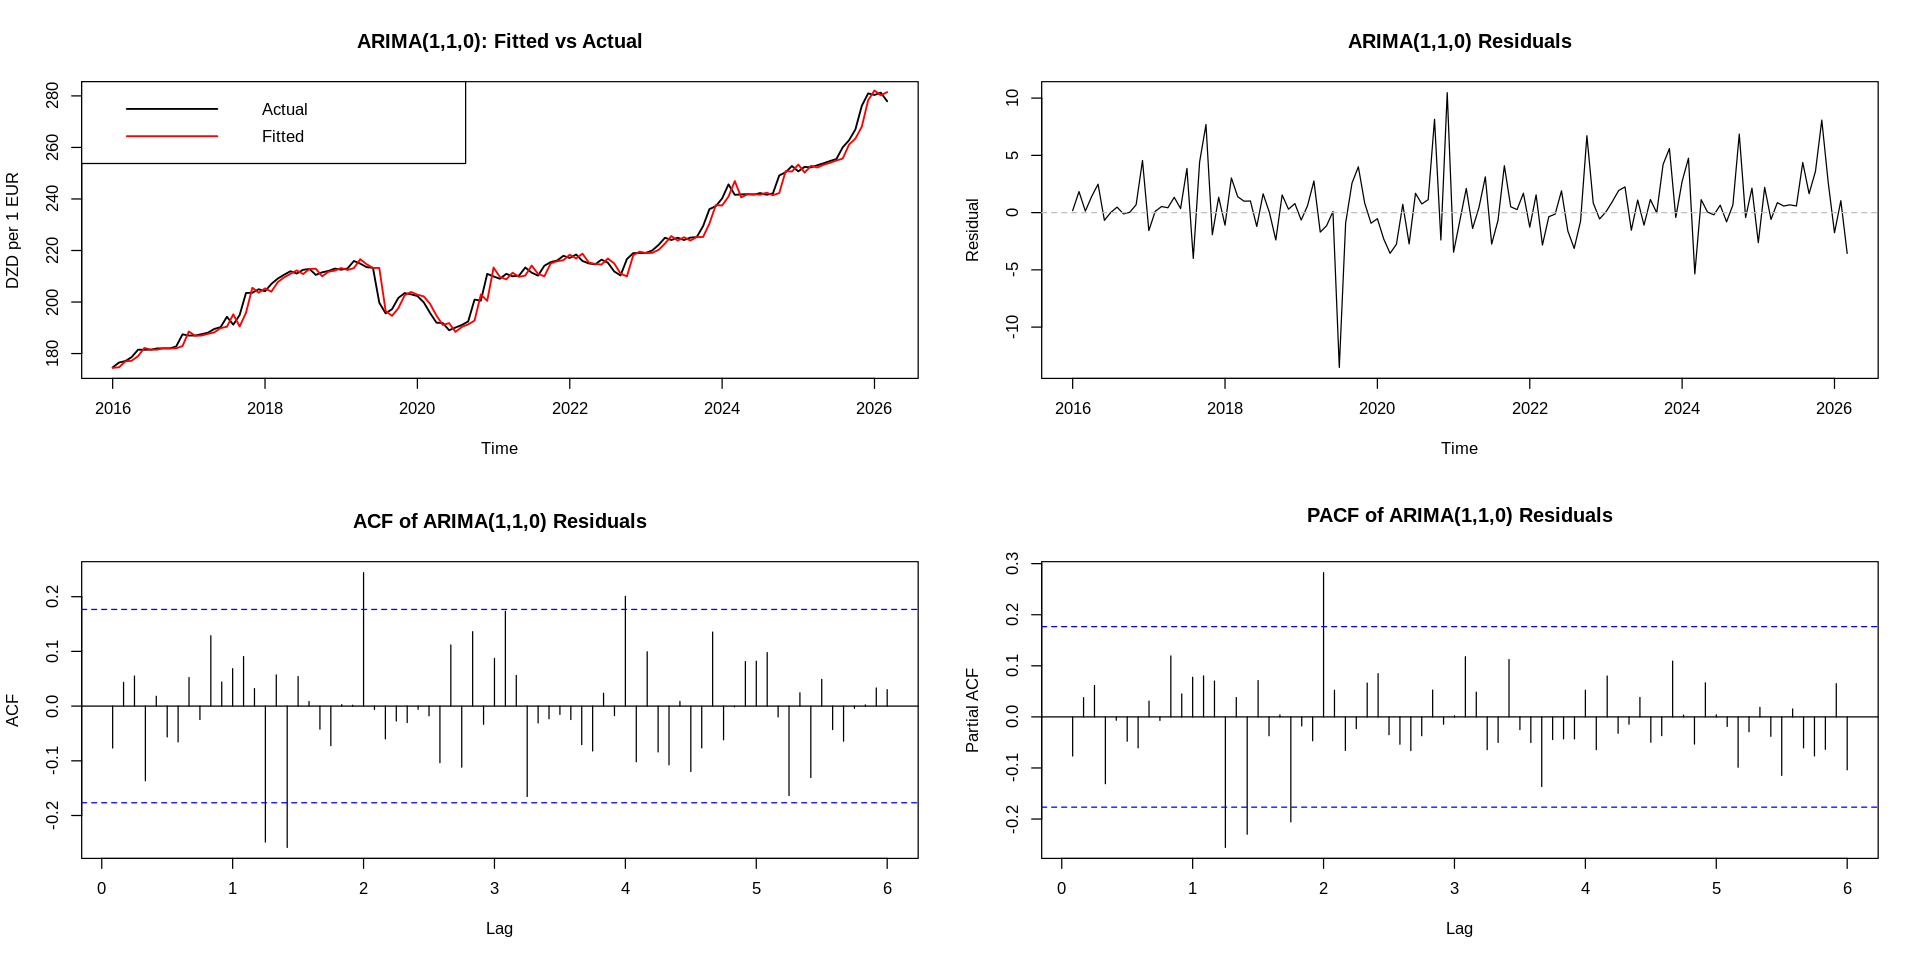

In [125]:
arima110 <- arima(y,order = c(1, 1, 0))
res_arima110 <- residuals(arima110)

par(mfrow=c(2,2))

plot(y, main="ARIMA(1,1,0): Fitted vs Actual", ylab="DZD per 1 EUR", lwd=1.5)
lines(fitted(arima110), col="red", lwd=1.5)
legend("topleft", legend=c("Actual","Fitted"), col=c("black","red"), lwd=1.5)

plot(res_arima110, main="ARIMA(1,1,0) Residuals", ylab="Residual")
abline(h=0, lty=2, col="grey")

acf(res_arima110,  lag.max=72, main="ACF of ARIMA(1,1,0) Residuals")
pacf(res_arima110, lag.max=72, main="PACF of ARIMA(1,1,0) Residuals")

- The **fitted vs actual** plot (top-left) shows the model successfully captures the general upward trend, the issue is the shocks causing the fitted line to lag behind (ARIMA models cannot capture exogenous shocks), and this appears in the first shock that happened in Sep 2017 (PM admits crisis), also in the later shocks like the COVID-related spikes that are lagging very much.


- The **ACF of residuals** (Bottom-left) show some white-noise behavior, though a few large residuals stand out, the ACF shows significant spikes at lag (24,36,48..), and this is likely due to the seasonality in the data that the pure ARIMA model cannot capture.

- The **PACF of residuals** (bottom-right) mostly white-noise with a significant spike at **lag 24** crosses the upper boundary, and a large negative spike appears around **lag 18**. The fact that lag 24 appears as significant in **both** ACF and PACF simultaneously is a stronger signal that a seasonal component may be missing from the model.

- The **residuals over time** plot (top-right) shows residuals fluctuating around zero with no visible trend or drift, which is a good sign. However, the **large negative spike around 2019–2020** dominates the plot and inflates the overall variance estimate. Outside of this event, the residuals appear roughly stable. No heteroskedasticity is obvious in the non-shock periods.

- **Overall conclusion:** The ARIMA(1,1,0) is a statistically adequate baseline but leaves some structure uncaptured — particularly the seasonal component in residuals and the sensitivity to the exogenous shocks.

In [126]:
cat("AR(1) coef :", coef(arima110), "\n")
cat("Sigma^2    :", arima110$sigma2, "\n")
cat("AIC        :", arima110$aic, "\n")
cat("s.e        :", arima110$var.coef, "\n")
cat("Log-lik    :", arima110$loglik, "\n")
Box.test(res_arima110, lag=12, type="Ljung-Box")

AR(1) coef : 0.2365371 
Sigma^2    : 8.764878 
AIC        : 613.1104 
s.e        : 0.007763186 
Log-lik    : -305.5552 



	Box-Ljung test

data:  res_arima110
X-squared = 8.4011, df = 12, p-value = 0.7531


**Result — ARIMA(1,1,0) Fit and Diagnostics:**
- The estimated **AR(1) coefficient** is $\phi_1 = 0.2365$ with a standard error of $\text{s.e.} = \sqrt{0.007763} = 0.0881$, giving a z-statistic of $z = 0.2365 / 0.0881 = 2.68 > 1.96$, which means it is **statistically significant at the 5% level**. This confirms a modest but meaningful positive autocorrelation in the differenced series — month-to-month changes in DZD/EUR tend to slightly persist in the same direction.

- The estimated **noise variance** is $\sigma^2 = 8.765$ DZD², which translates to a residual standard deviation of $\sqrt{8.765} \approx 2.96$ DZD — meaning the model's typical one-step prediction error is roughly **±3 DZD**, which is reasonable given the series ranges from 175 to 280 DZD.

- The **log-likelihood** is $\ell = -305.56$, and the **AIC = 613.11**. This will serve as our baseline benchmark — any more complex model must achieve a meaningfully lower AIC to justify its additional parameters.

- The **Ljung-Box test** at lag  gives $\chi^2(12) = 8.40$, $p = 0.753 \gg 0.05$, so we **fail to reject $H_0$**: the residuals show no statistically significant autocorrelation **up to lag 12**, confirming the model has adequately captured the short-term dependence structure, but in the previous analysis, the significant spike at lag 24 in the ACF/PACF suggests a seasonal component is still missing -> we will need to consider a seasonal ARIMA extension.


	Shapiro-Wilk normality test

data:  res_arima110
W = 0.91546, p-value = 1.02e-06



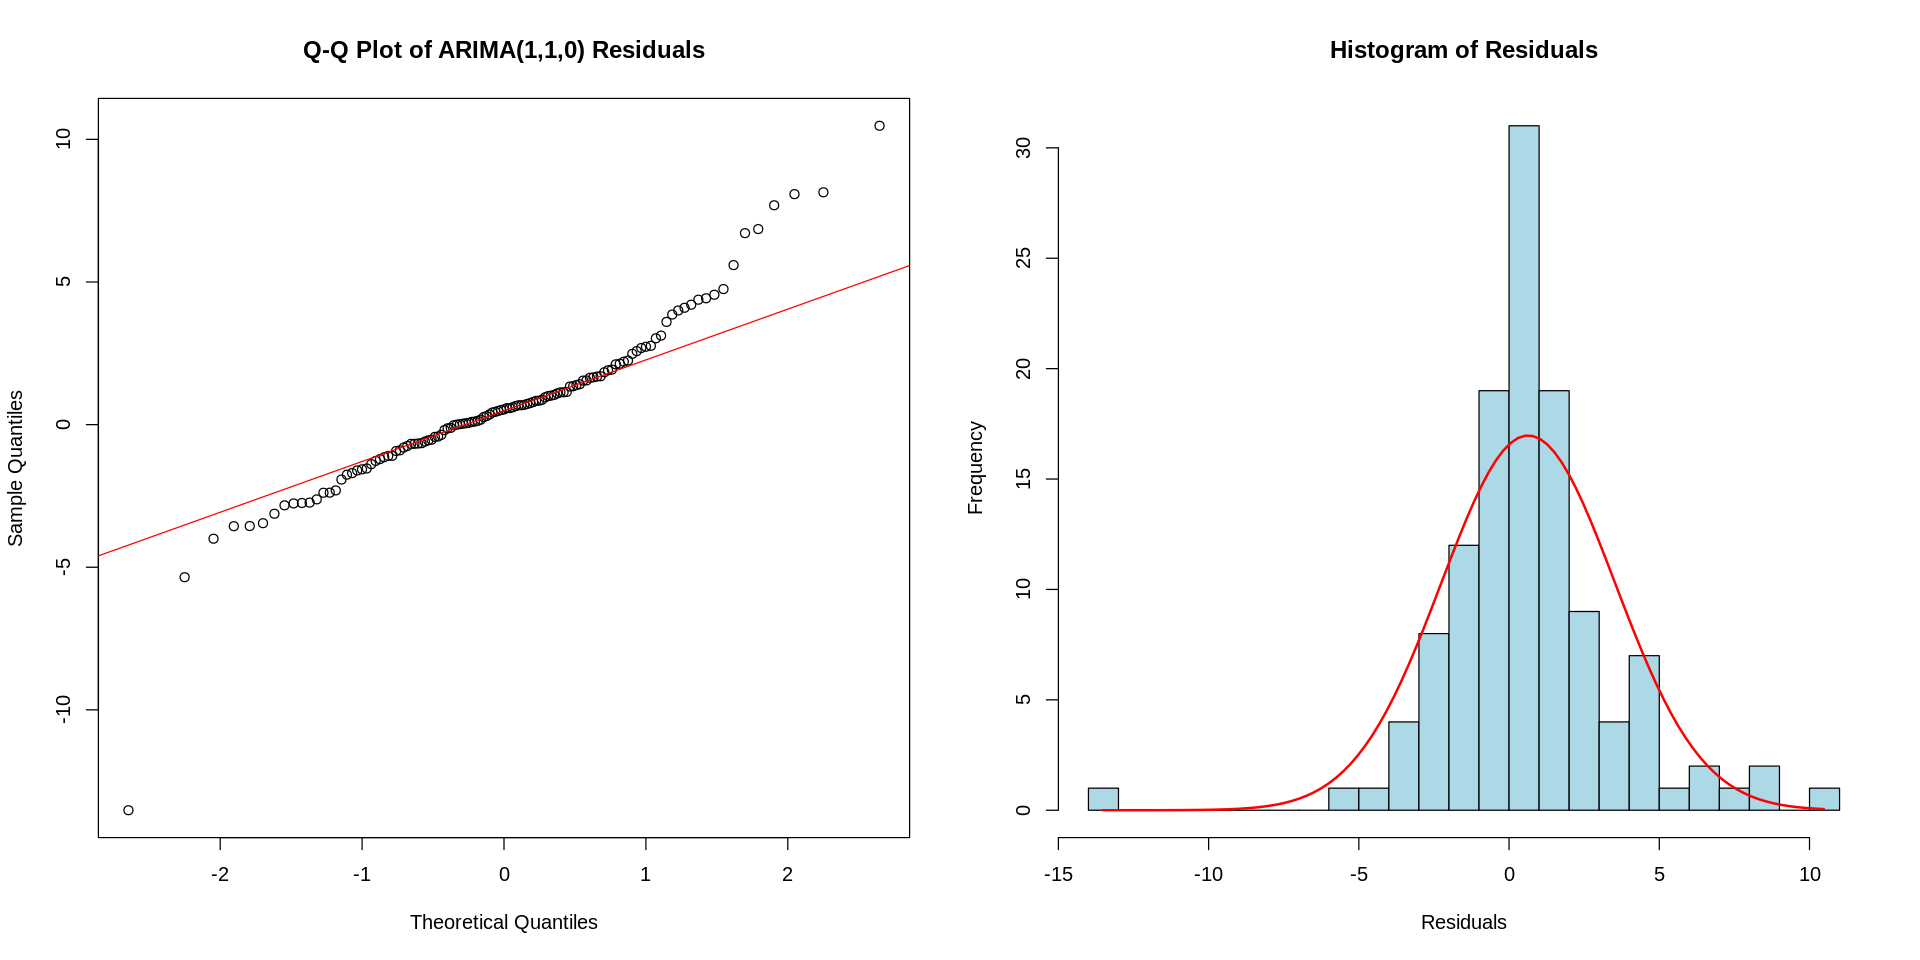

In [127]:

shapiro_test <- shapiro.test(res_arima110)
print(shapiro_test)

par(mfrow=c(1,2))

qqnorm(res_arima110, main="Q-Q Plot of ARIMA(1,1,0) Residuals")
qqline(res_arima110, col="red")

h <- hist(res_arima110, breaks=20, col="lightblue",main="Histogram of Residuals", xlab="Residuals")

x_vals <- seq(min(res_arima110), max(res_arima110), length=100)
y_vals <- dnorm(x_vals, mean=mean(res_arima110), sd=sd(res_arima110))
y_vals <- y_vals * diff(h$mids[1:2]) * length(res_arima110)

lines(x_vals, y_vals, col="red", lwd=2)

**Result — Normality Test for ARIMA(1,1,0) Residuals:**
- The Shapiro-Wilk test gives **p-value = 1.02 × 10⁻⁶ <<< 0.05**,  .
- We **reject $H_0$**: the residuals of ARIMA(1,1,0) are **not normally distributed**.
- The **Q-Q plot** confirms this: the tails deviate noticeably from the theoretical line, indicating heavier tails than a normal distribution.
- The **histogram** shows the residuals are roughly centered around zero but with some extreme values, corresponding to the exogenous shocks in the data.
    - **Interpretation:** The non-normality is driven by the large spikes (Hirak, COVID-19, car import policy, etc.) and the seasonal patterns.

### SARIMA with $D=1$

We use `arima()` with the `seasonal` argument to fit a **SARIMA(1,1,0)(1,1,0)[12]** model.
This adds:
- **Seasonal differencing** ($D=1$): $\nabla_{12} Y_t = Y_t - Y_{t-12}$
- **Seasonal AR(1)** ($P=1$): autoregressive term at the seasonal lag

The seasonal differencing forces the model to "remember" the pattern from 12 months ago and project it forward, rather than converging to a flat line.

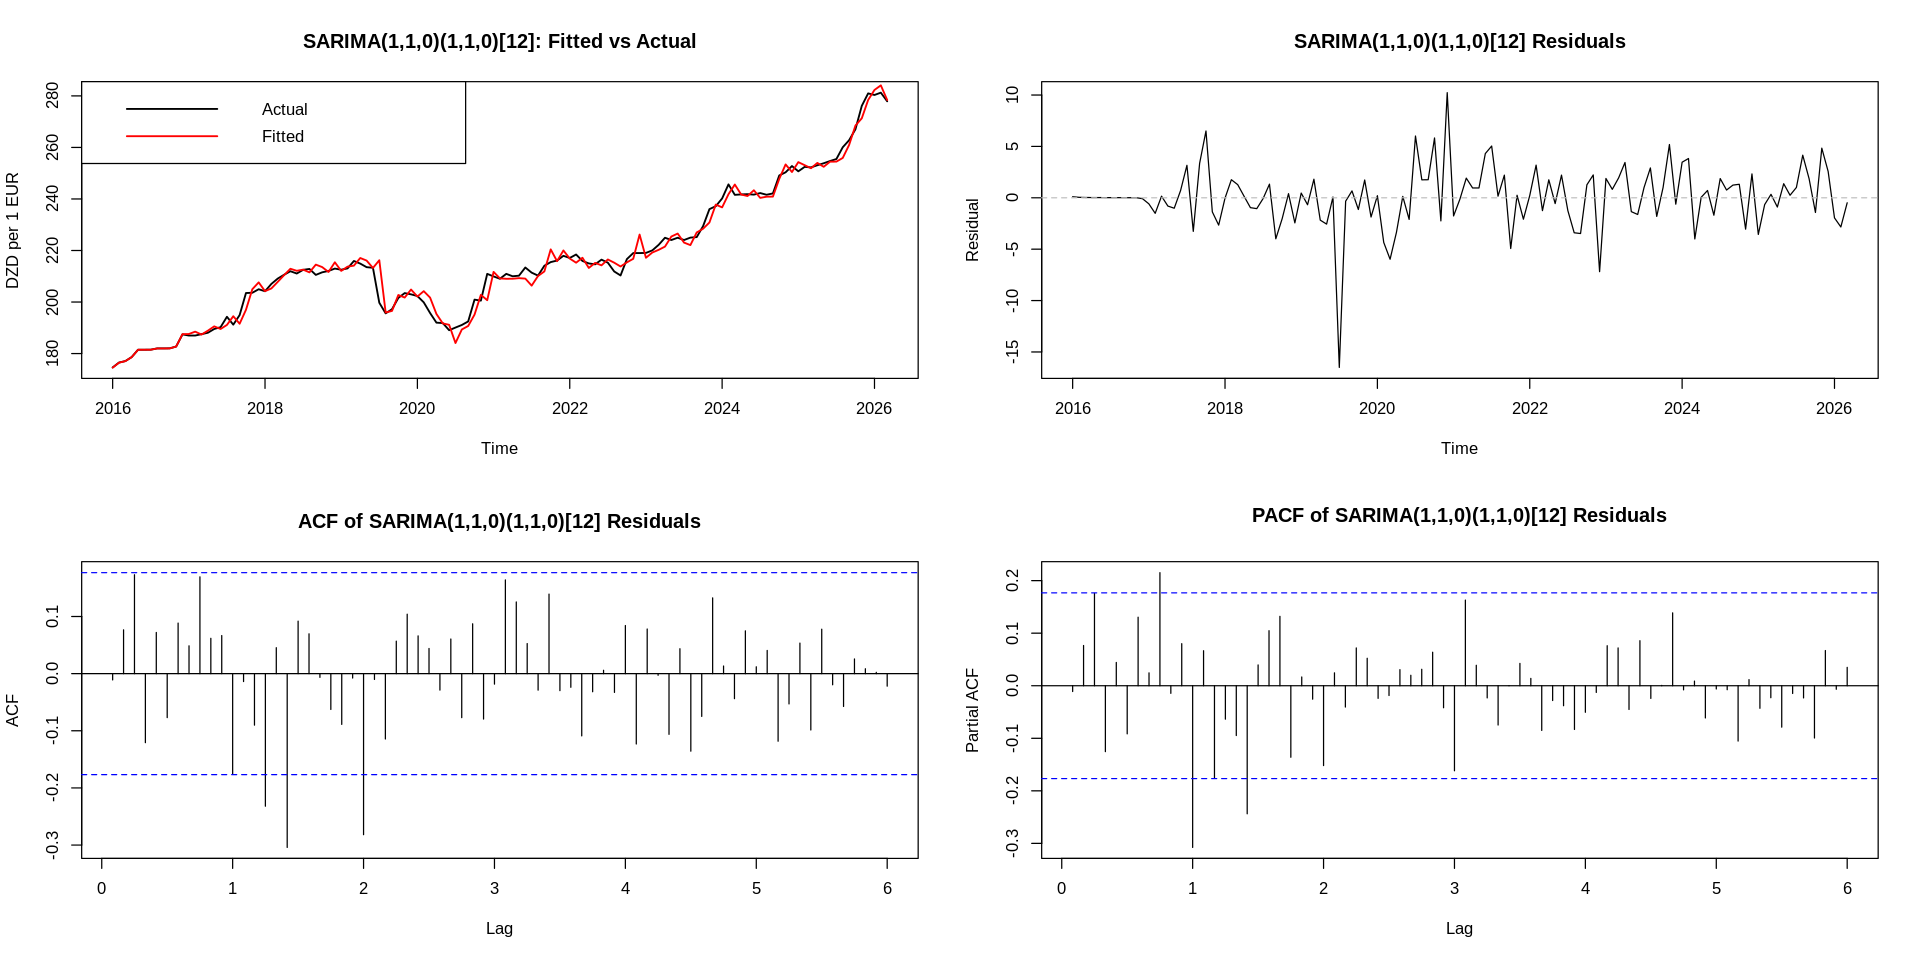

In [128]:
# ══════════════════════════════════════════════════════════════
# SARIMA(1,1,0)(1,1,0)[12] — Full Diagnostics
# ══════════════════════════════════════════════════════════════
sarima110_110 <- arima(y, order = c(1, 1, 0),
                       seasonal = list(order = c(1, 1, 0), period = 12),
                       method = "ML")
res_sarima <- residuals(sarima110_110)

par(mfrow = c(2, 2))

plot(y, main = "SARIMA(1,1,0)(1,1,0)[12]: Fitted vs Actual", ylab = "DZD per 1 EUR", lwd = 1.5)
lines(fitted(sarima110_110), col = "red", lwd = 1.5)
legend("topleft", legend = c("Actual", "Fitted"), col = c("black", "red"), lwd = 1.5)

plot(res_sarima, main = "SARIMA(1,1,0)(1,1,0)[12] Residuals", ylab = "Residual")
abline(h = 0, lty = 2, col = "grey")

acf(res_sarima,  lag.max = 72, main = "ACF of SARIMA(1,1,0)(1,1,0)[12] Residuals")
pacf(res_sarima, lag.max = 72, main = "PACF of SARIMA(1,1,0)(1,1,0)[12] Residuals")

**Result — SARIMA(1,1,0)(1,1,0)[12] Fit and Diagnostics:**

- The **fitted vs actual** plot (top-left) shows similar (or worse!) in-sample tracking to ARIMA(1,1,0), the same exogenous shocks (2017, COVID 2019–2020, 2026 surge) still cause the fitted line to lag (unavoidable).

- The **residuals over time** (top-right) fluctuate around zero with no trend, but the **COVID spike is now larger (≈ −16 DZD)** compared to ARIMA(1,1,0)'s −12 DZD -> seasonal differencing amplifies the shock by comparing it against the pre-pandemic baseline 12 months earlier.

- The **ACF of residuals** (bottom-left) significant spikes at lags 12, 24, 15 and 17 (because of the exogenous shocks).

- The **PACF of residuals** (bottom-right) significant spikes at lags 9, 12 and 17 cross the boundary.

In [129]:
cat("AR(1) coef  :", coef(sarima110_110)["ar1"], "\n")
cat("SAR(1) coef :", coef(sarima110_110)["sar1"], "\n")
cat("Sigma^2     :", sarima110_110$sigma2, "\n")
cat("AIC         :", sarima110_110$aic, "\n")
cat("Log-lik     :", sarima110_110$loglik, "\n")

Box.test(res_sarima, lag = 12, type = "Ljung-Box")

AR(1) coef  : 0.1280941 
SAR(1) coef : -0.5910175 
Sigma^2     : 9.807021 
AIC         : 572.4803 
Log-lik     : -284.2402 



	Box-Ljung test

data:  res_sarima
X-squared = 18.57, df = 12, p-value = 0.09944



**Result — SARIMA(1,1,0)(1,1,0)[12] Parameter Estimates & Tests:**

- **AR(1):** $\phi_1 = 0.1281$ (down from 0.2365) — the seasonal component absorbed part of the short-term autocorrelation. **SAR(1):** $\Phi_1 = -0.591$, large and negative, suggesting the model may be over-correcting the seasonal structure.

- **$\sigma^2 = 9.807$** — **higher** than ARIMA(1,1,0)'s 8.765, meaning worse one-step prediction error despite the added complexity.

- **AIC = 572.48** vs 613.11 — a drop of ~40 points seemingly favoring SARIMA, but this must be read alongside the Ljung-Box result.

- The **Ljung-Box test** at lag 12 gives $\chi^2(12) = 18.57$, $p = 0.099 \gg 0.05$, so we **fail to reject $H_0$**: the residuals show no statistically significant autocorrelation **up to lag 12**.


	Shapiro-Wilk normality test

data:  res_sarima
W = 0.90327, p-value = 2.19e-07



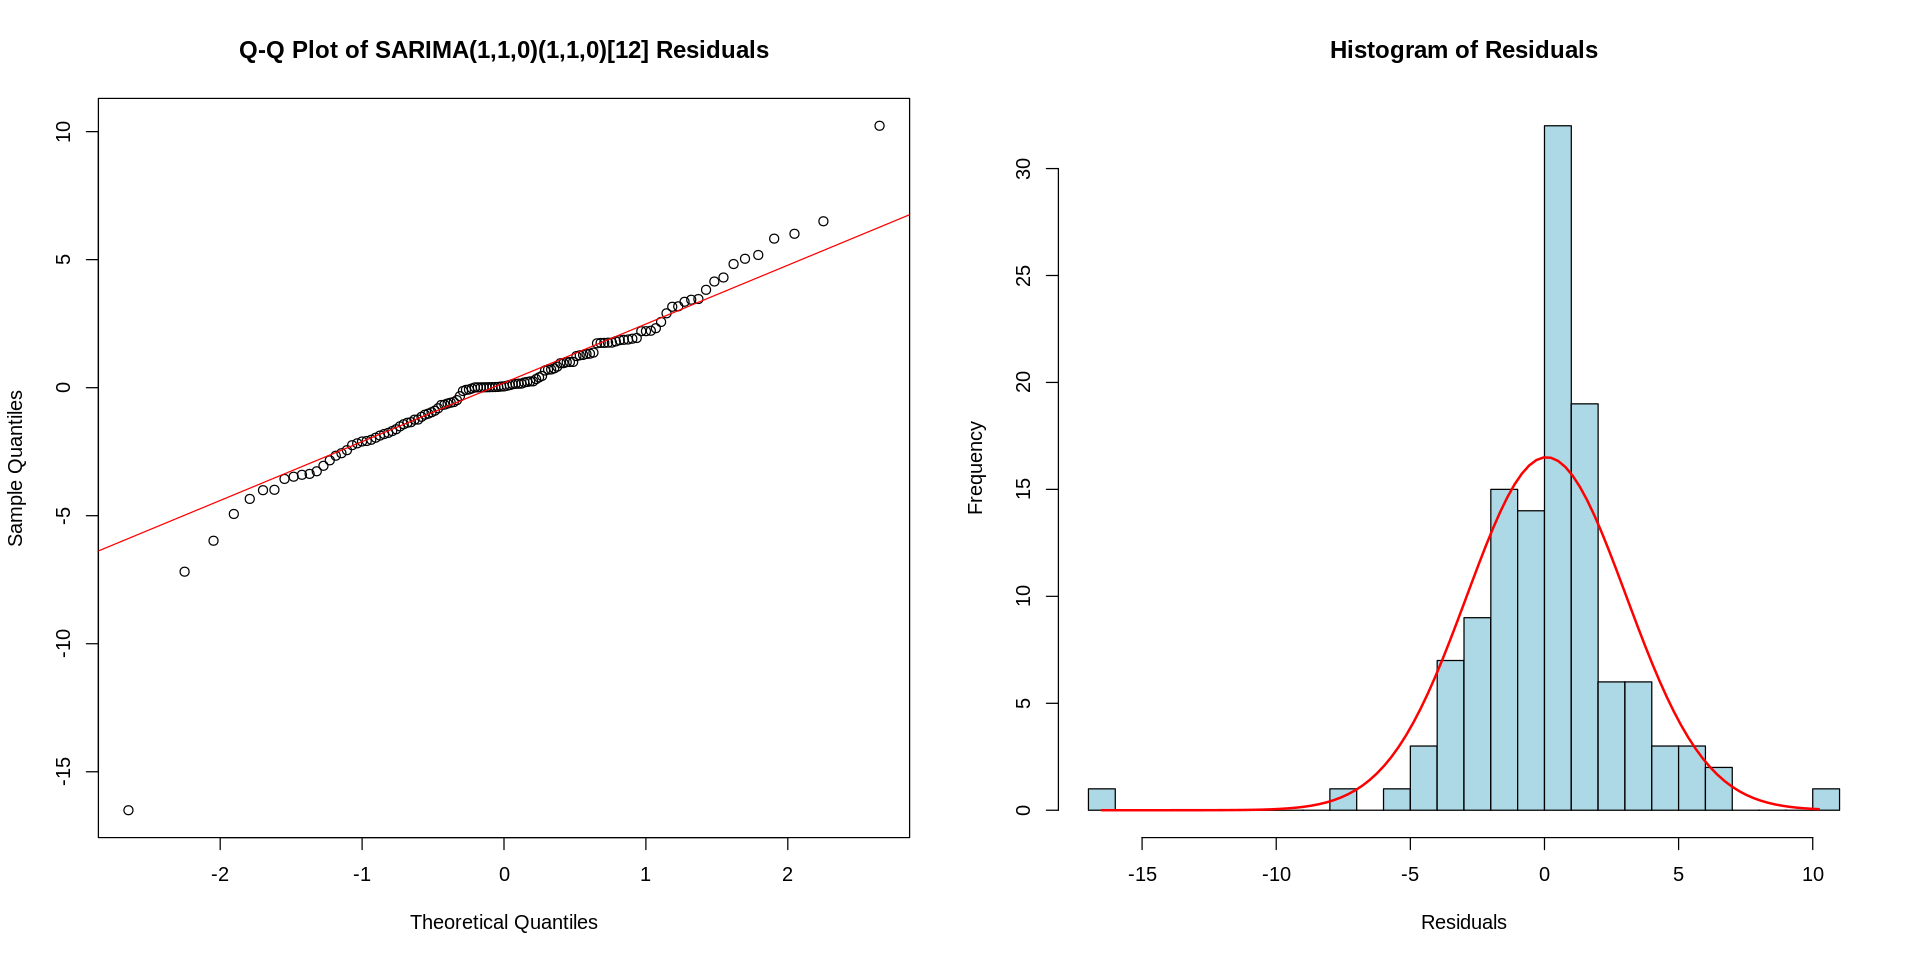

In [130]:

shapiro_test_sarima <- shapiro.test(res_sarima)
print(shapiro_test_sarima)

par(mfrow = c(1, 2))

qqnorm(res_sarima, main = "Q-Q Plot of SARIMA(1,1,0)(1,1,0)[12] Residuals")
qqline(res_sarima, col = "red")

h <- hist(res_sarima, breaks = 20, col = "lightblue",
          main = "Histogram of Residuals", xlab = "Residuals")
x_vals <- seq(min(res_sarima), max(res_sarima), length = 100)
y_vals <- dnorm(x_vals, mean = mean(res_sarima), sd = sd(res_sarima))
y_vals <- y_vals * diff(h$mids[1:2]) * length(res_sarima)
lines(x_vals, y_vals, col = "red", lwd = 2)


**Result — Normality of SARIMA(1,1,0)(1,1,0)[12] Residuals:**

- The **Shapiro-Wilk test** gives $p = 2.19 \times 10^{-7} \ll 0.05$ — we **reject $H_0$**, so the residuals are **not normally distributed**, the same conclusion as for ARIMA(1,1,0).
- The **Q-Q plot** shows both tails deviating sharply from the theoretical line.
- The **histogram** is right-skewed with a sharp peak near zero and a long left tail — the normal curve clearly fails to fit, again because of the large exogenous shocks.

**Conclusion:** The SARIMA(1,1,0)(1,1,0)[12] model still passes the Ljung-Box check at lag 12, but residual normality remains violated because the series contains shocks that the model cannot anticipate.

## Section 4: Forecasting


### Forcasting with ARIMA(1,1,0):

RMSE: 18.74 DZD
MAE : 15.67 DZD


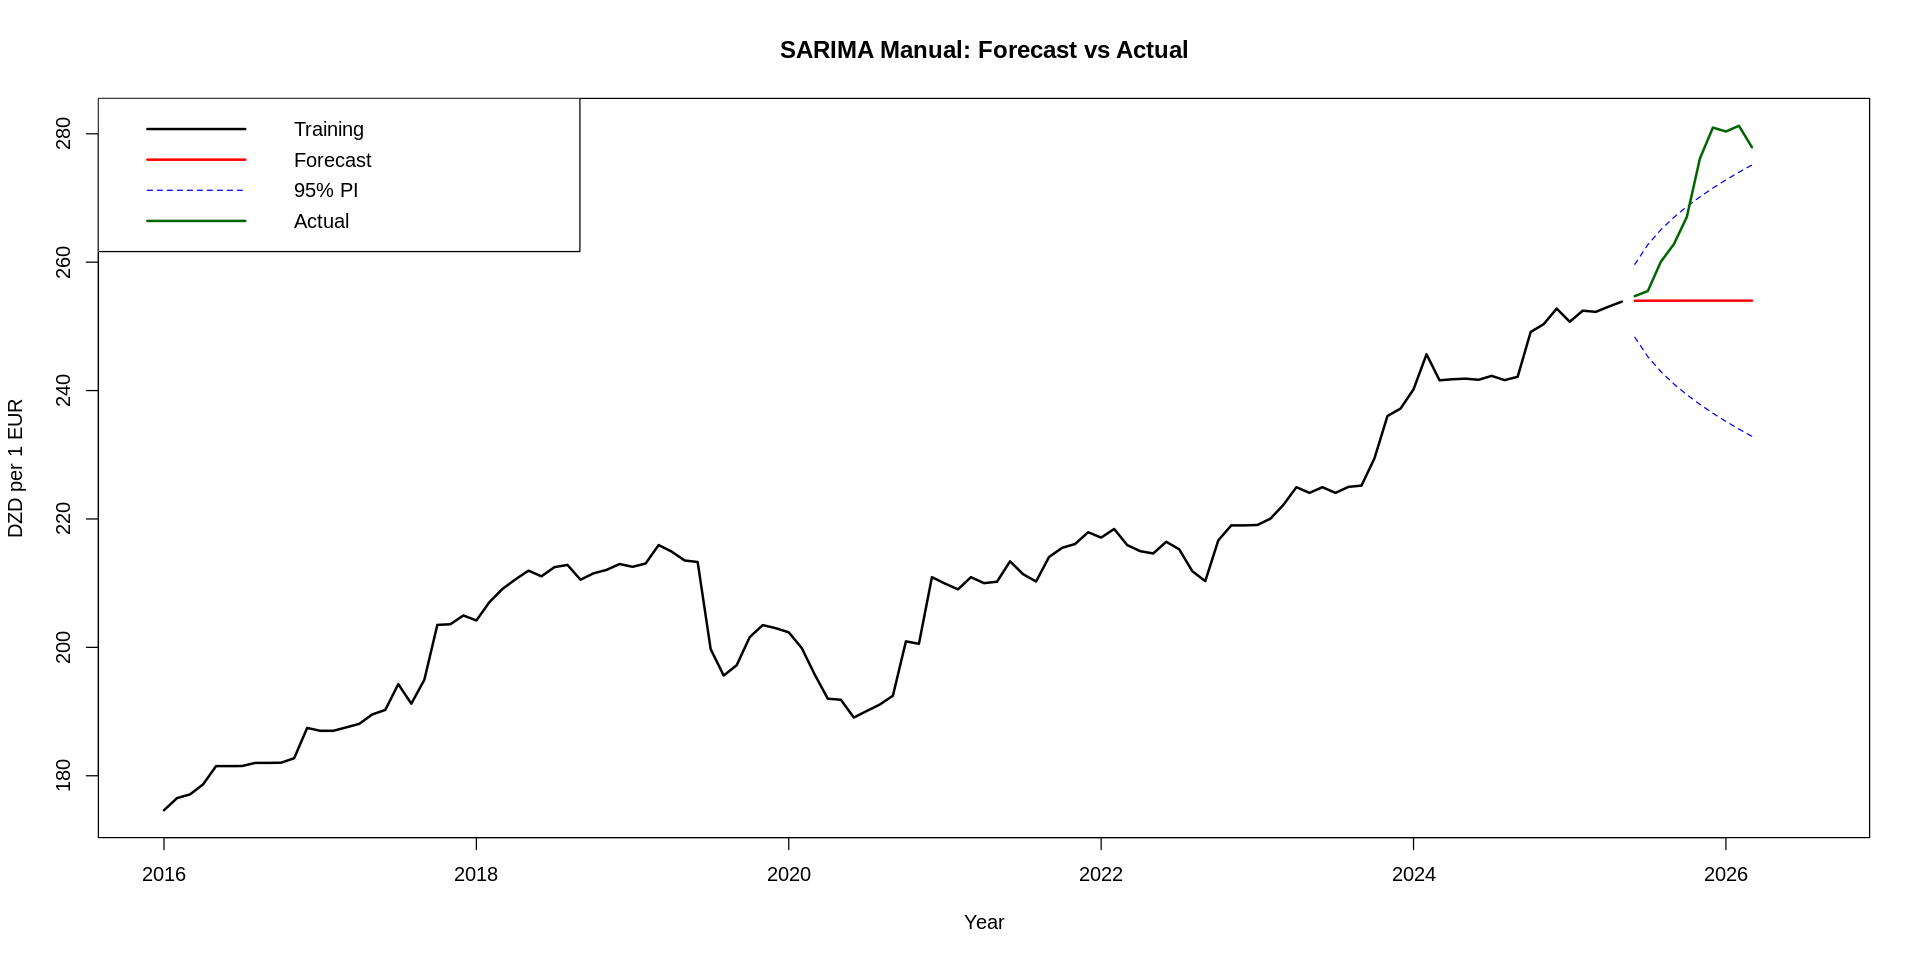

In [131]:
n       <- length(y)
n_test  <- 10
y_train <- ts(y[1:(n - n_test)], start = c(2016, 1), frequency = 12)
y_test  <- y[(n - n_test + 1):n]

# ── Refit on training data ────────────────────────────────────
sarima_manual <- arima(y_train, order = c(1, 1, 0)
                       )
# ── Generate forecasts ────────────────────────────────────────
fc <- predict(sarima_manual, n.ahead = n_test)

forecast_values <- as.numeric(fc$pred)
actual_values   <- as.numeric(y_test)
lower_ci        <- as.numeric(fc$pred - 1.96 * fc$se)
upper_ci        <- as.numeric(fc$pred + 1.96 * fc$se)

start_date <- as.Date(paste0(floor(time(y)[n - n_test + 1]), "-",
              sprintf("%02d", cycle(y)[n - n_test + 1]), "-01"))
comparison <- data.frame(
  Month    = format(seq(start_date, by = "month", length.out = n_test), "%Y-%m"),
  Actual   = round(actual_values, 2),
  Forecast = round(forecast_values, 2),
  Lower95  = round(lower_ci, 2),
  Upper95  = round(upper_ci, 2),
  Error    = round(actual_values - forecast_values, 2)
)

rmse <- sqrt(mean(comparison$Error^2))
mae  <- mean(abs(comparison$Error))
cat("RMSE:", round(rmse, 2), "DZD\n")
cat("MAE :", round(mae,  2), "DZD\n")

par(mfrow = c(1, 1))
plot(y_train, xlim = c(2016, 2026.5),
     ylim = range(c(y, upper_ci, lower_ci)),
     main = "SARIMA Manual: Forecast vs Actual",
     ylab = "DZD per 1 EUR", xlab = "Year", lwd = 2)
lines(ts(forecast_values, start = time(y)[n - n_test + 1], frequency = 12),
      col = "red", lwd = 2)
lines(ts(upper_ci, start = time(y)[n - n_test + 1], frequency = 12),
      col = "blue", lty = 2)
lines(ts(lower_ci, start = time(y)[n - n_test + 1], frequency = 12),
      col = "blue", lty = 2)
lines(ts(actual_values, start = time(y)[n - n_test + 1], frequency = 12),
      col = "darkgreen", lwd = 2)
legend("topleft",
       legend = c("Training", "Forecast", "95% PI", "Actual"),
       col = c("black", "red", "blue", "darkgreen"),
       lty = c(1, 1, 2, 1), lwd = c(2, 2, 1, 2))

**Result — Pure ARIMA(1,1,0) Forecast:**

The model is $\nabla Y_t = \phi_1 \nabla Y_{t-1} + \varepsilon_t$ with $\phi_1 = 0.2365$. Since $|\phi_1| < 1$, the forecast increments decay as $\phi_1^h \to 0$, causing predictions to **converge to a flat line** (~254 DZD) within just a few steps — this is expected behavior for a non-seasonal ARIMA.

- The **actual values (green)** surged sharply from \~254 to \~280 DZD over the forecast window — a rise of \~26 DZD that the model entirely missed. The upper 95% PI band (\~270 DZD) was breached for most of the horizon, which is a serious failure.

- **RMSE = 18.74 DZD** and **MAE = 15.67 DZD** confirm this — an average error of ~16 DZD represents roughly **6% of the full series range**, which is poor by any standard.

- **Root cause:** The model has no seasonal component — it applies only regular differencing ($d=1$) but not seasonal differencing ($D=1$). Without $Y_t - Y_{t-12}$, it cannot encode the yearly cycle and cannot project seasonal momentum forward, this confirms the pure ARIMA(1,1,0) is too simple for this series.

**Conclusion:** All diagnostics and forecast results motivate extending to a **SARIMA(1,1,0)(1,1,0)[12]** model, which adds seasonal differencing and a seasonal AR term to explicitly capture the yearly depreciation cycle.

### Forecasting with SARIMA(1,1,0)(1,1,0)[12]:

RMSE: 9.31 DZD
MAE : 8.13 DZD


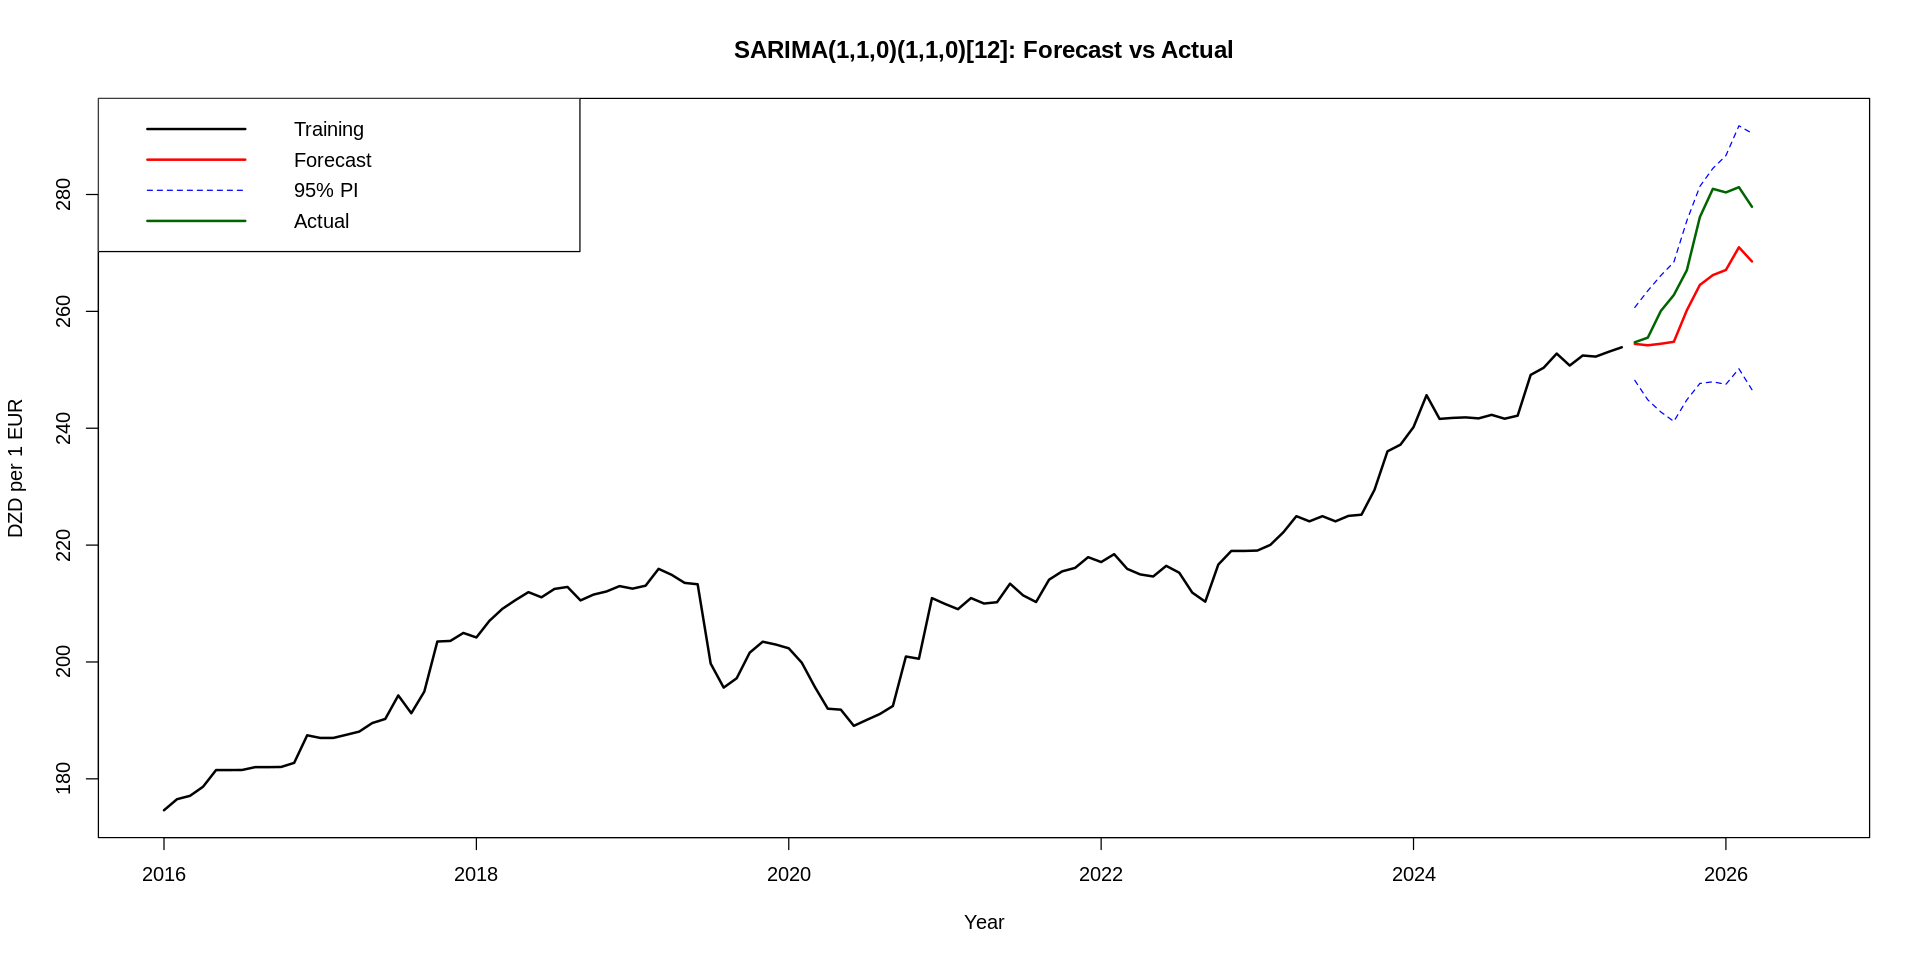

In [132]:
n       <- length(y)
n_test  <- 10
y_train <- ts(y[1:(n - n_test)], start = c(2016, 1), frequency = 12)
y_test  <- y[(n - n_test + 1):n]

# ── Refit on training data ────────────────────────────────────
sarima110_110 <- arima(y_train, order = c(1, 1, 0),
                       seasonal = list(order = c(1, 1, 0), period = 12),
                       method = "ML")

fc <- predict(sarima110_110, n.ahead = n_test)

forecast_values <- as.numeric(fc$pred)
actual_values   <- as.numeric(y_test)
lower_ci        <- as.numeric(fc$pred - 1.96 * fc$se)
upper_ci        <- as.numeric(fc$pred + 1.96 * fc$se)

start_date <- as.Date(paste0(floor(time(y)[n - n_test + 1]), "-",
              sprintf("%02d", cycle(y)[n - n_test + 1]), "-01"))
comparison <- data.frame(
  Month    = format(seq(start_date, by = "month", length.out = n_test), "%Y-%m"),
  Actual   = round(actual_values, 2),
  Forecast = round(forecast_values, 2),
  Lower95  = round(lower_ci, 2),
  Upper95  = round(upper_ci, 2),
  Error    = round(actual_values - forecast_values, 2)
)

rmse <- sqrt(mean(comparison$Error^2))
mae  <- mean(abs(comparison$Error))
cat("RMSE:", round(rmse, 2), "DZD\n")
cat("MAE :", round(mae,  2), "DZD\n")

par(mfrow = c(1, 1))
plot(y_train, xlim = c(2016, 2026.5),
     ylim = range(c(y, upper_ci, lower_ci)),
     main = "SARIMA(1,1,0)(1,1,0)[12]: Forecast vs Actual",
     ylab = "DZD per 1 EUR", xlab = "Year", lwd = 2)
lines(ts(forecast_values, start = time(y)[n - n_test + 1], frequency = 12),
      col = "red", lwd = 2)
lines(ts(upper_ci, start = time(y)[n - n_test + 1], frequency = 12),
      col = "blue", lty = 2)
lines(ts(lower_ci, start = time(y)[n - n_test + 1], frequency = 12),
      col = "blue", lty = 2)
lines(ts(actual_values, start = time(y)[n - n_test + 1], frequency = 12),
      col = "darkgreen", lwd = 2)
legend("topleft",
       legend = c("Training", "Forecast", "95% PI", "Actual"),
       col = c("black", "red", "blue", "darkgreen"),
       lty = c(1, 1, 2, 1), lwd = c(2, 2, 1, 2))

**Result — SARIMA(1,1,0)(1,1,0)[12] forecast:**

- Unlike the pure ARIMA(1,1,0), the SARIMA forecast is **no longer a flat line** — it captures the seasonal pattern and projects it forward.
- The seasonal differencing $D=1$ forces the model to use $Y_t - Y_{t-12}$ (current month minus same month last year), which explicitly encodes the yearly cycle.
- The prediction intervals widen over time, reflecting increasing uncertainty for longer horizons.

**Conclusion:** Adding seasonal differencing solves the flat-forecast problem. The model can now be used to forecast the EUR/DZD black-market rate with meaningful seasonal variation, but the large exogenous shocks remain a challenge for accurate forecasting, hence we may use other models that can capture these shocks (e.g. SARIMAX with exogenous regressors) in future work.

## Section 5: Discussion

### Summary

This project applied the Box-Jenkins methodology to model and forecast the EUR/DZD black market exchange rate using monthly data from January 2016 to March 2026. The analysis followed the standard stages of specification, diagnostics, and forecasting, while keeping the main political, policy, and COVID-related shocks in view throughout the interpretation.

**Model specification** began with a Box-Cox analysis, which showed that no variance-stabilizing transformation was required because $\lambda = 1$ lay within the confidence interval. The Augmented Dickey-Fuller test confirmed that the original series was non-stationary (p = 0.937), while first differencing produced stationarity (p = 0.01), establishing the differencing order $d = 1$. ACF and PACF analysis of the differenced series, together with BIC-based model selection via `armasubsets()`, identified **ARIMA(1,1,0)** as the best parsimonious non-seasonal candidate.

**Fitting and diagnostics** showed that ARIMA(1,1,0) is a reasonable statistical baseline: its residuals pass the Ljung-Box test at lag 12, but residual ACF/PACF plots and the out-of-sample forecast reveal that the model does not capture the clear yearly pattern in the data, and the resulted residuals failed the normality test. This motivated the extension to **SARIMA(1,1,0)(1,1,0)[12]**, which adds seasonal differencing and a seasonal AR term. The SARIMA model produces forecasts that follow the observed seasonal rise-and-fall pattern instead of collapsing to a flat path.

**Residual diagnostics** The Shapiro-Wilk test still rejects normality (p = 2.19 × 10⁻⁷), showing that the residual distribution remains heavy-tailed because of large exogenous shocks such as Hirak, COVID-19, car-import policy changes, and fiscal stress.

**Forecasting** used a hold-out strategy based on the last 10 observations: the model was fitted on the first 113 monthly values and then used to forecast the final 10 months. Compared with the pure ARIMA benchmark, the SARIMA forecast is materially more realistic because it preserves seasonal variation, even though unexpected shocks still limit accuracy and make prediction intervals less reliable than under ideal Gaussian assumptions.

### Main Problems Encountered

The main challenge in this analysis was the presence of **large exogenous shocks**. Events such as the Hirak (2019), the COVID-19 pandemic (2020), car-import policy changes (2022–2023), and fiscal pressures (2025) generated abrupt jumps that standard ARIMA-family models cannot predict from past values alone.

This creates two practical problems. First, the residuals are not normally distributed, so the usual Gaussian prediction intervals should be interpreted with caution. Second, forecast errors can become large whenever a new policy or political shock hits the market, even if the underlying seasonal and autoregressive structure has been captured correctly.

Several extensions could improve the analysis in future work:
- **Outlier detection and intervention modeling** for known shocks.
- **Robust estimation methods** that are less sensitive to extreme observations.
- **SARIMAX or ARIMAX models** with exogenous regressors such as policy indicators, oil prices, or official exchange rates.
- **Bootstrap-based prediction intervals** that do not rely on the normality assumption.

### Conclusions

The main empirical conclusion is that **SARIMA(1,1,0)(1,1,0)[12]** is a more credible forecasting model for the EUR/DZD parallel rate than the pure ARIMA(1,1,0) benchmark. The non-seasonal model is useful as a parsimonious baseline, but its flat forecasts make it inadequate for practical forecasting when the data contain a recurring yearly pattern. The SARIMA specification corrects that weakness by incorporating seasonal differencing and seasonal autoregression.

At the same time, the informal nature of the parallel market means that no purely statistical model can fully anticipate abrupt changes driven by politics, regulation, mobility restrictions, or fiscal stress. For that reason, the model's point forecasts remain informative, but its prediction intervals should always be interpreted alongside current economic and political context.